# Consolidação dos resultados de treinamento — Windows × Mac

**Notebook reproduzível e pré-executado**  
Snapshot UTC: `2026-09-15T23:21:11+00:00`  
Branch de consolidação: `consolidacao-de-resultados`  
Commit Windows: `037ebfe492fc22c7d7e8eb569a09da6c685261cd`  
Ref/commit Mac: `origin/codex/mac-training-split` / `ac18558739f10b021ef39c68e8e944e567bf414f`

Este notebook reúne os resultados finais, métricas por classe, matrizes de confusão, curvas por epoch, duração e telemetria. As comparações foram separadas em (1) pares batch equivalentes e (2) pares de ativações apenas descritivos, porque o batch e a pilha de software diferem entre os ambientes.


## Como reproduzir

1. Execute `analysis/consolidacao_resultados/consolidate_results.py` para reconstruir os CSVs a partir dos artefatos Windows locais e da referência Git do Mac.
2. Execute `analysis/consolidacao_resultados/render_figures.py` para reconstruir os gráficos estáticos.
3. Abra este notebook a partir da raiz do repositório e execute todas as células em ordem.

O notebook não altera os artefatos originais de treinamento.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
ROOT = next(path for path in candidate_roots if (path / "analysis" / "consolidacao_resultados" / "data").exists())
BASE = ROOT / "analysis" / "consolidacao_resultados"
DATA = BASE / "data"
FIGURES = BASE / "figures"

def read(name):
    return pd.read_csv(DATA / f"{name}.csv")

summary = json.loads((DATA / "summary.json").read_text(encoding="utf-8"))
runs = read("run_results")
campaigns = read("campaign_summary")
coverage = read("evidence_coverage")
validation = read("validation_checks")
batch_pairs = read("comparisons_batch_windows_mac")
activation_pairs = read("comparisons_activation_windows_mac")
classes = read("class_metrics")
confusion = read("confusion_matrices_long")
epochs = read("epoch_metrics")
telemetry = read("telemetry_profiles")
telemetry_metrics = read("telemetry_metrics_long")
mac_batch_reported = read("reported_mac_batch_cells")
mac_quant_reported = read("reported_mac_quantization_status")
unmatched = read("unmatched_runs")
print(f"Carregados: {len(runs)} runs, {len(classes)} linhas por classe, {len(epochs)} epochs e {len(telemetry)} bins de telemetria.")


Carregados: 161 runs, 2307 linhas por classe, 10243 epochs e 2552 bins de telemetria.


## 1. Escopo e cobertura da evidência


Foram encontrados **119 runs Windows** e **42 runs Mac** com métricas finais exatas. Eles somam **12,943 epochs** e **436.59 horas-run** observadas.

No Mac, relatórios históricos registram execuções adicionais sem os artefatos numéricos completos versionados. Elas aparecem separadamente na seção de lacunas; não foram convertidas em métricas inventadas.


In [2]:
platform_summary = pd.DataFrame([
    {
        "plataforma": platform,
        "runs_com_metricas": values["completed_runs_with_metrics"],
        "campanhas": values["campaigns"],
        "datasets": values["datasets"],
        "epochs": values["epochs"],
        "horas_treinamento": values["training_hours_observed"],
        "runs_class_metrics": values["runs_with_class_metrics"],
        "runs_confusion_matrix": values["runs_with_confusion_matrix"],
        "runs_epoch_metrics": values["runs_with_epoch_metrics"],
        "runs_telemetria": values["runs_with_telemetry_summary"],
    }
    for platform, values in summary["platforms"].items()
])
platform_summary


plataforma,runs_com_metricas,campanhas,datasets,epochs,horas_treinamento,runs_class_metrics,runs_confusion_matrix,runs_epoch_metrics,runs_telemetria
Mac,42,2,9,3318,153.238934,33,15,15,42
Windows,119,6,9,9625,283.352955,119,119,118,118


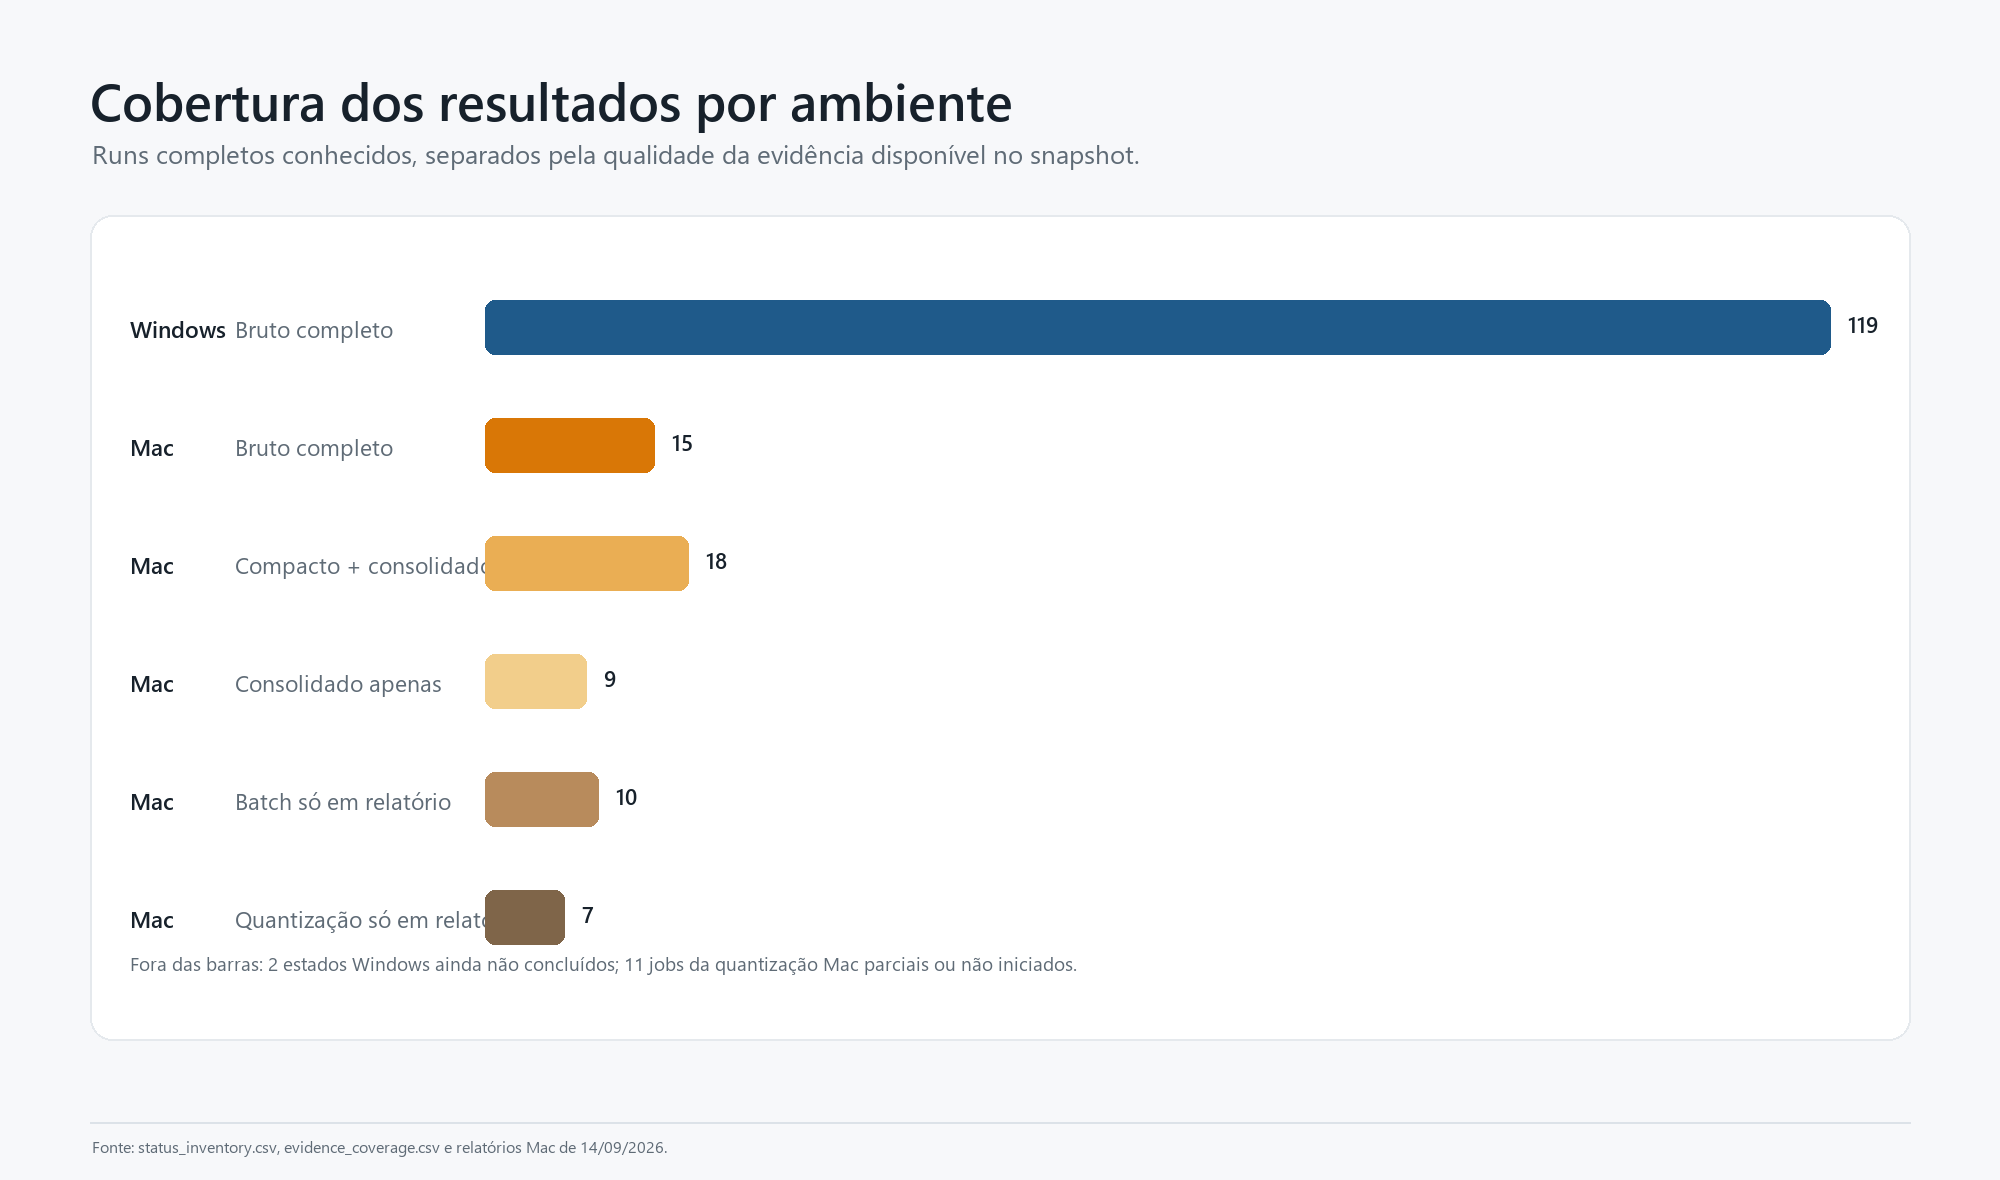

In [3]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / "01_cobertura_resultados.png")))


### Inventário dos dados normalizados


In [4]:
inventory = pd.DataFrame([
    ("run_results.csv", len(runs), "Uma linha por run com métricas finais, tempo, ambiente e telemetria resumida"),
    ("class_metrics.csv", len(classes), "Precisão, recall, F1 e suporte por classe"),
    ("confusion_matrices_long.csv", len(confusion), "Matrizes de confusão em formato longo"),
    ("epoch_metrics.csv", len(epochs), "Loss, acurácia, Macro F1, tempo e throughput por epoch"),
    ("telemetry_metrics_long.csv", len(telemetry_metrics), "Estatísticas de telemetria por run e métrica"),
    ("telemetry_profiles.csv", len(telemetry), "Perfis temporais normalizados de telemetria"),
    ("comparisons_batch_windows_mac.csv", len(batch_pairs), "Pares batch com configuração/split equivalentes"),
    ("comparisons_activation_windows_mac.csv", len(activation_pairs), "Pares de ativação descritivos, com batch diferente"),
    ("unmatched_runs.csv", len(unmatched), "Runs sem contraparte comparável entre plataformas"),
], columns=["arquivo", "linhas", "conteudo"])
inventory


arquivo,linhas,conteudo
run_results.csv,161,"Uma linha por run com métricas finais, tempo, ambiente e telemetria resumida"
class_metrics.csv,2307,"Precisão, recall, F1 e suporte por classe"
confusion_matrices_long.csv,47954,Matrizes de confusão em formato longo
epoch_metrics.csv,10243,"Loss, acurácia, Macro F1, tempo e throughput por epoch"
telemetry_metrics_long.csv,22872,Estatísticas de telemetria por run e métrica
telemetry_profiles.csv,2552,Perfis temporais normalizados de telemetria
comparisons_batch_windows_mac.csv,6,Pares batch com configuração/split equivalentes
comparisons_activation_windows_mac.csv,21,"Pares de ativação descritivos, com batch diferente"
unmatched_runs.csv,107,Runs sem contraparte comparável entre plataformas


## 2. Validações de integridade


Os checks abaixo confirmam unicidade dos identificadores, limites das métricas, recomposição do Macro F1 pelas classes, totais das matrizes e contagens de epochs.


In [5]:
validation


check,status,observed,expected,detail
run_uid_unique,pass,0.0,0,"Chave composta por plataforma, campanha, fase, dataset, variante, seed e tentativa."
metrics_in_unit_interval,pass,0.0,0,Métricas de classificação devem permanecer entre 0 e 1.
macro_f1_recomputed_from_classes,pass,0.0,<=1e-9,152 runs com relatório por classe comparável.
confusion_matrix_totals,pass,0.0,0,134 matrizes confrontadas com o total de teste.
epoch_counts_match_summary,pass,0.0,0,133 runs com série por época.
activation_pair_count,pass,21.0,21,Pares disponíveis para sete datasets e três ativações; GTSRB e FER2013 ainda não têm resultado Windows final no snapshot.
batch_pair_count,pass,6.0,6,Pares com artefatos brutos versionados nos dois ambientes.


## 3. Campanhas, duração e ambiente de execução


In [6]:
campaign_view = campaigns[["platform","campaign","phase","completed_runs","datasets","epochs","training_hours","mean_macro_f1","mean_accuracy","median_epoch_seconds","weighted_gpu_util_mean_pct","weighted_ram_mean_pct"]].sort_values(["platform","campaign","phase"])
campaign_view


platform,campaign,phase,completed_runs,datasets,epochs,training_hours,mean_macro_f1,mean_accuracy,median_epoch_seconds,weighted_gpu_util_mean_pct,weighted_ram_mean_pct
Mac,controlled-augmentation05-activations-mac2,activation,27,9,2700,99.461690,0.475218,0.532290,117.143361,87.711351,74.144453
Mac,controlled-augmentation2-mac-m4-aug05,batch,6,3,600,53.747402,0.962710,0.962856,265.351381,75.442814,75.828895
Mac,controlled-augmentation2-mac-m4-aug05,smoke,9,9,18,0.029842,0.109679,0.165730,4.686671,16.833333,56.370175
Windows,controlled-augmentation05-batch-activation,activation,21,7,2100,54.267025,0.560824,0.588745,78.132247,33.212145,34.453050
Windows,controlled-augmentation05-batch-activation,batch,36,9,3600,83.701377,0.813601,0.819289,50.143316,27.557772,30.806567
Windows,controlled-augmentation2,batch,12,3,1200,63.656769,0.969033,0.969158,209.536073,26.834525,32.220177
Windows,kmnist-alldata-noaug-batch-sweep-2026-08-06,batch,32,1,1600,27.661800,0.977172,0.977164,58.568403,24.638967,21.805587
Windows,kmnist-batch32-noaugmentation-control-2026-08-28,control,1,1,100,2.567250,0.986569,0.986571,92.420990,28.175154,26.364838
Windows,kmnist-quantization-2026-08-09,quantization,5,1,200,2.201285,0.975053,0.975067,39.980029,39.287671,23.433009
Windows,remaining-ram-capped,balance,12,3,825,49.297450,0.763207,0.771471,227.860473,21.532874,44.111230


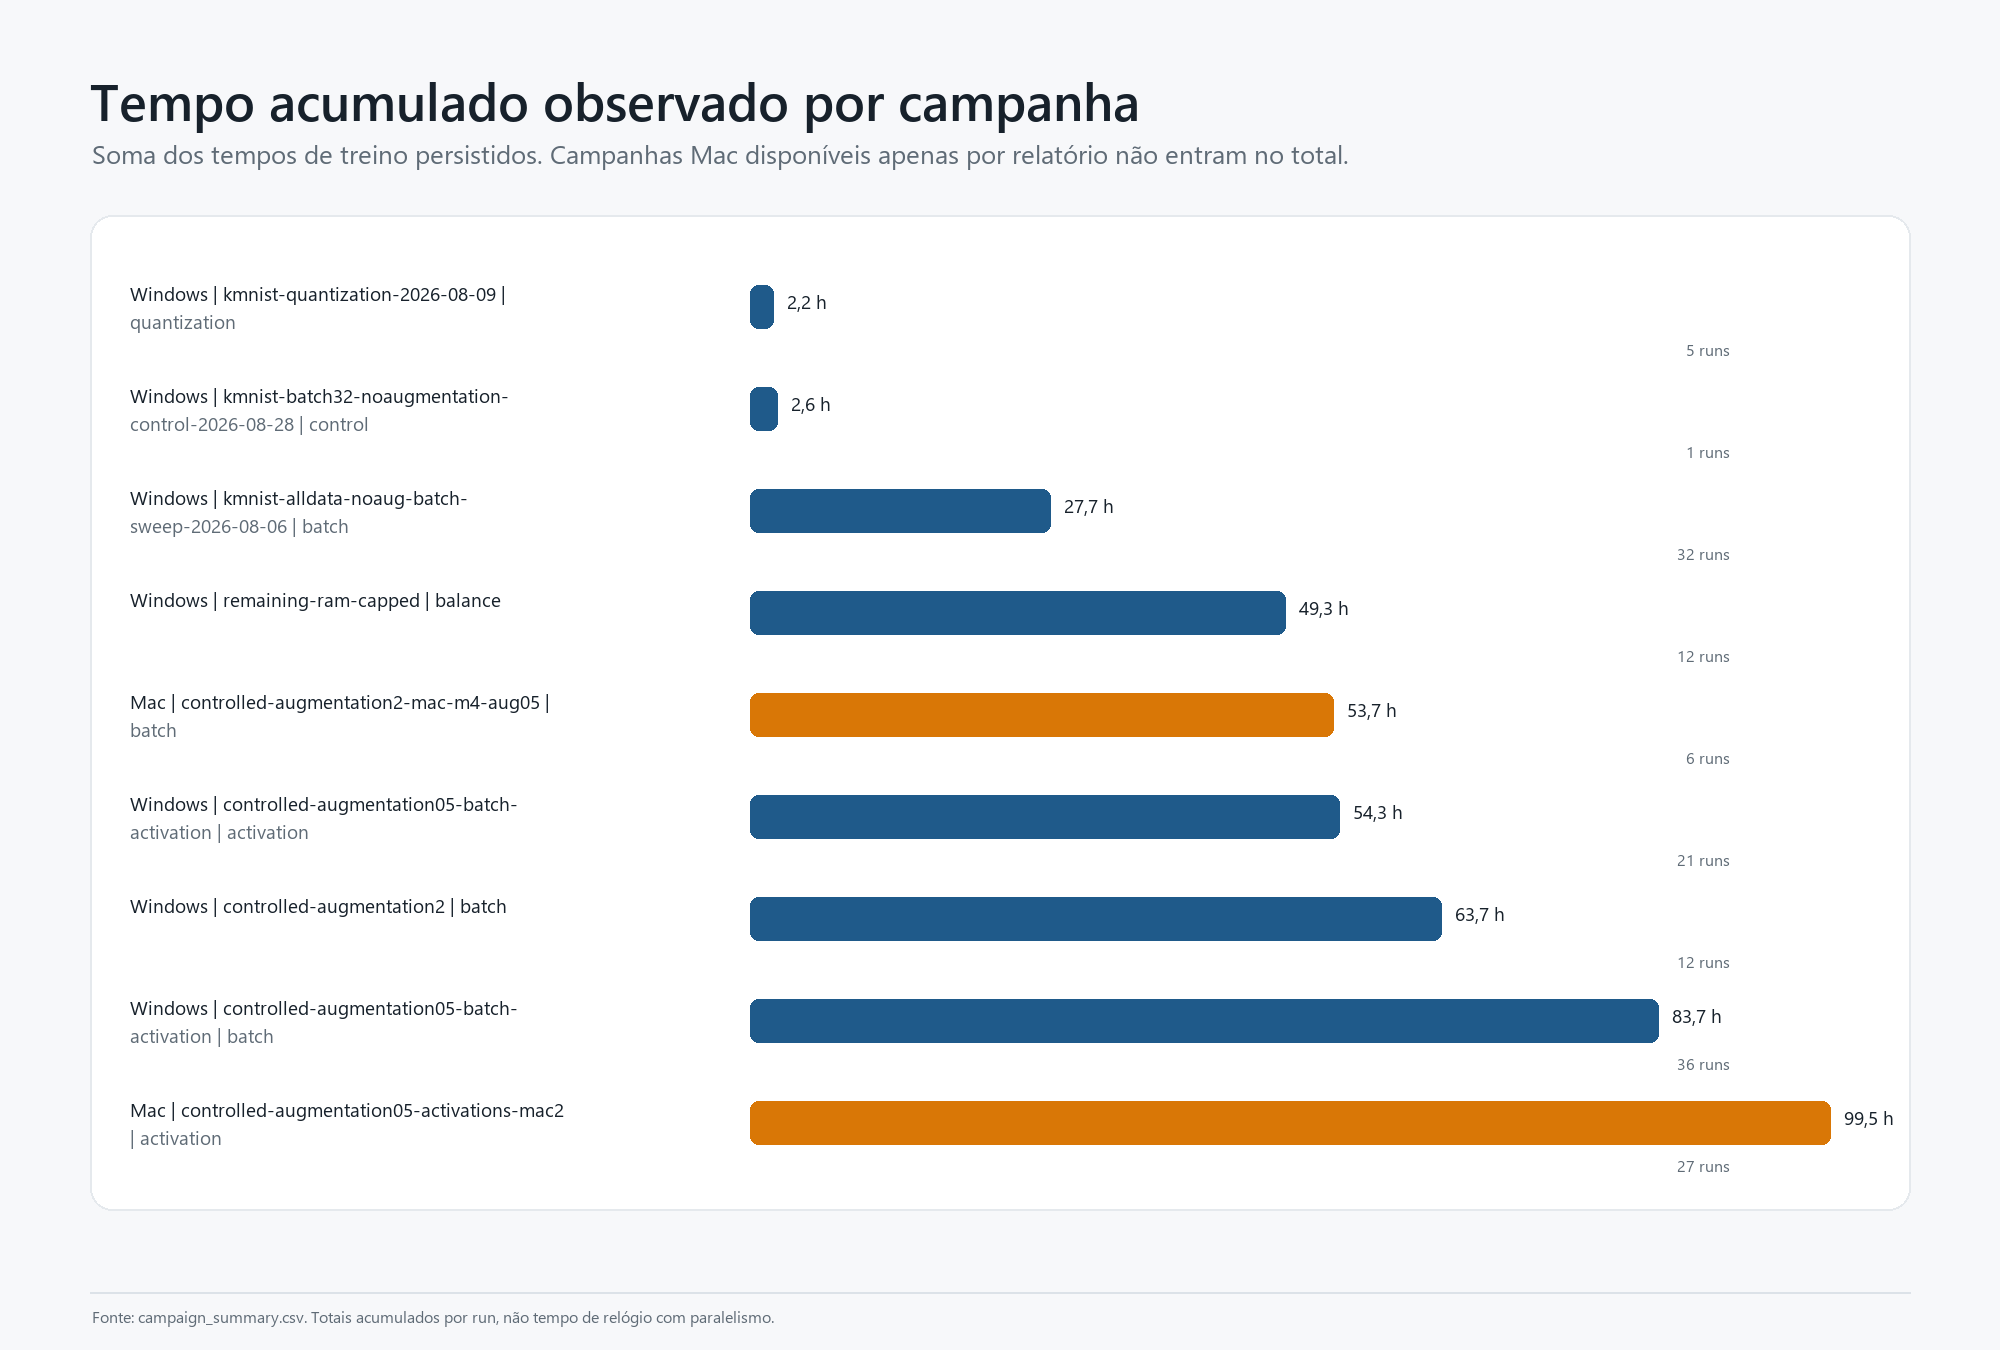

In [7]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / "02_tempo_acumulado_campanhas.png")))


### Hardware e pilha de software observados


In [8]:
hardware = (runs.groupby(["platform","gpu_name","gpu_backend","tensorflow_version","tensorflow_metal_version"], dropna=False).agg(runs=("run_uid","nunique"), horas=("training_hours","sum")).reset_index())
hardware


platform,gpu_name,gpu_backend,tensorflow_version,tensorflow_metal_version,runs,horas
Mac,Apple M4,apple-metal-ioreg,2.18.1,1.2.0,42,153.238934
Windows,NVIDIA RTX A2000 12GB,pynvml,2.21.0,NaN,70,204.192420
Windows,NVIDIA GeForce RTX 3050,pynvml,2.21.0,NaN,48,79.160535
Windows,NaN,NaN,NaN,NaN,1,0.000000


## 4. Resultados completos dos treinamentos


A tabela pré-executada contém todos os 161 runs com métricas finais exatas disponíveis. `loss` deve ser minimizado; acurácia, Macro Precision, Macro Recall e Macro F1 devem ser maximizados.


In [9]:
result_columns = ["platform","campaign","phase","dataset","variant","batch_size","activation","quantization_variant","accuracy","balanced_accuracy","macro_precision","macro_recall","macro_f1","loss","epochs_completed","training_hours","mean_epoch_seconds","gpu_name","tensorflow_version","evidence_level"]
all_results = runs[result_columns].sort_values(["platform","campaign","phase","dataset","variant"])
all_results


platform,campaign,phase,dataset,variant,batch_size,activation,quantization_variant,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,loss,epochs_completed,training_hours,mean_epoch_seconds,gpu_name,tensorflow_version,evidence_level
Mac,controlled-augmentation05-activations-mac2,activation,CIFAR-10,relu,256,relu,NaN,0.566444,0.566444,0.588146,0.566444,0.564456,1.160675,100.0,3.197870,115.123336,Apple M4,2.18.1,raw_compact_plus_consolidated
Mac,controlled-augmentation05-activations-mac2,activation,CIFAR-10,sigmoid,256,sigmoid,NaN,0.636667,0.636667,0.647898,0.636667,0.638977,1.012245,100.0,3.945816,142.049362,Apple M4,2.18.1,raw_compact_plus_consolidated
Mac,controlled-augmentation05-activations-mac2,activation,CIFAR-10,softmax,256,softmax,NaN,0.100000,0.100000,0.010000,0.100000,0.018182,2.302591,100.0,3.159323,113.735643,Apple M4,2.18.1,raw_compact_plus_consolidated
Mac,controlled-augmentation05-activations-mac2,activation,CIFAR-100 coarse,relu,256,relu,NaN,0.303222,0.303222,0.369046,0.303222,0.299782,2.257801,100.0,3.172328,114.203819,Apple M4,2.18.1,raw_compact_plus_consolidated
Mac,controlled-augmentation05-activations-mac2,activation,CIFAR-100 coarse,sigmoid,256,sigmoid,NaN,0.366111,0.366111,0.362627,0.366111,0.350154,2.052153,100.0,3.948196,142.135061,Apple M4,2.18.1,raw_compact_plus_consolidated
Mac,controlled-augmentation05-activations-mac2,activation,CIFAR-100 coarse,softmax,256,softmax,NaN,0.050000,0.050000,0.002500,0.050000,0.004762,2.995737,100.0,3.214273,115.713818,Apple M4,2.18.1,raw_compact_plus_consolidated
Mac,controlled-augmentation05-activations-mac2,activation,EMNIST Balanced,relu,256,relu,NaN,0.848632,0.848632,0.859475,0.848632,0.844157,0.568742,100.0,3.814315,236.750569,Apple M4,2.18.1,raw_compact_plus_consolidated
Mac,controlled-augmentation05-activations-mac2,activation,EMNIST Balanced,sigmoid,256,sigmoid,NaN,0.852786,0.852786,0.859336,0.852786,0.849283,0.436212,100.0,8.439008,303.804290,Apple M4,2.18.1,raw_compact_plus_consolidated
Mac,controlled-augmentation05-activations-mac2,activation,EMNIST Balanced,softmax,256,softmax,NaN,0.021277,0.021277,0.000453,0.021277,0.000887,3.850156,100.0,6.801580,244.856882,Apple M4,2.18.1,raw_compact_plus_consolidated
Mac,controlled-augmentation05-activations-mac2,activation,FER2013,relu,256,relu,NaN,0.403196,0.333266,0.242565,0.333266,0.274679,1.432635,100.0,1.676353,60.348725,Apple M4,2.18.1,consolidated_report_only


### Melhores batches observados no Windows por dataset


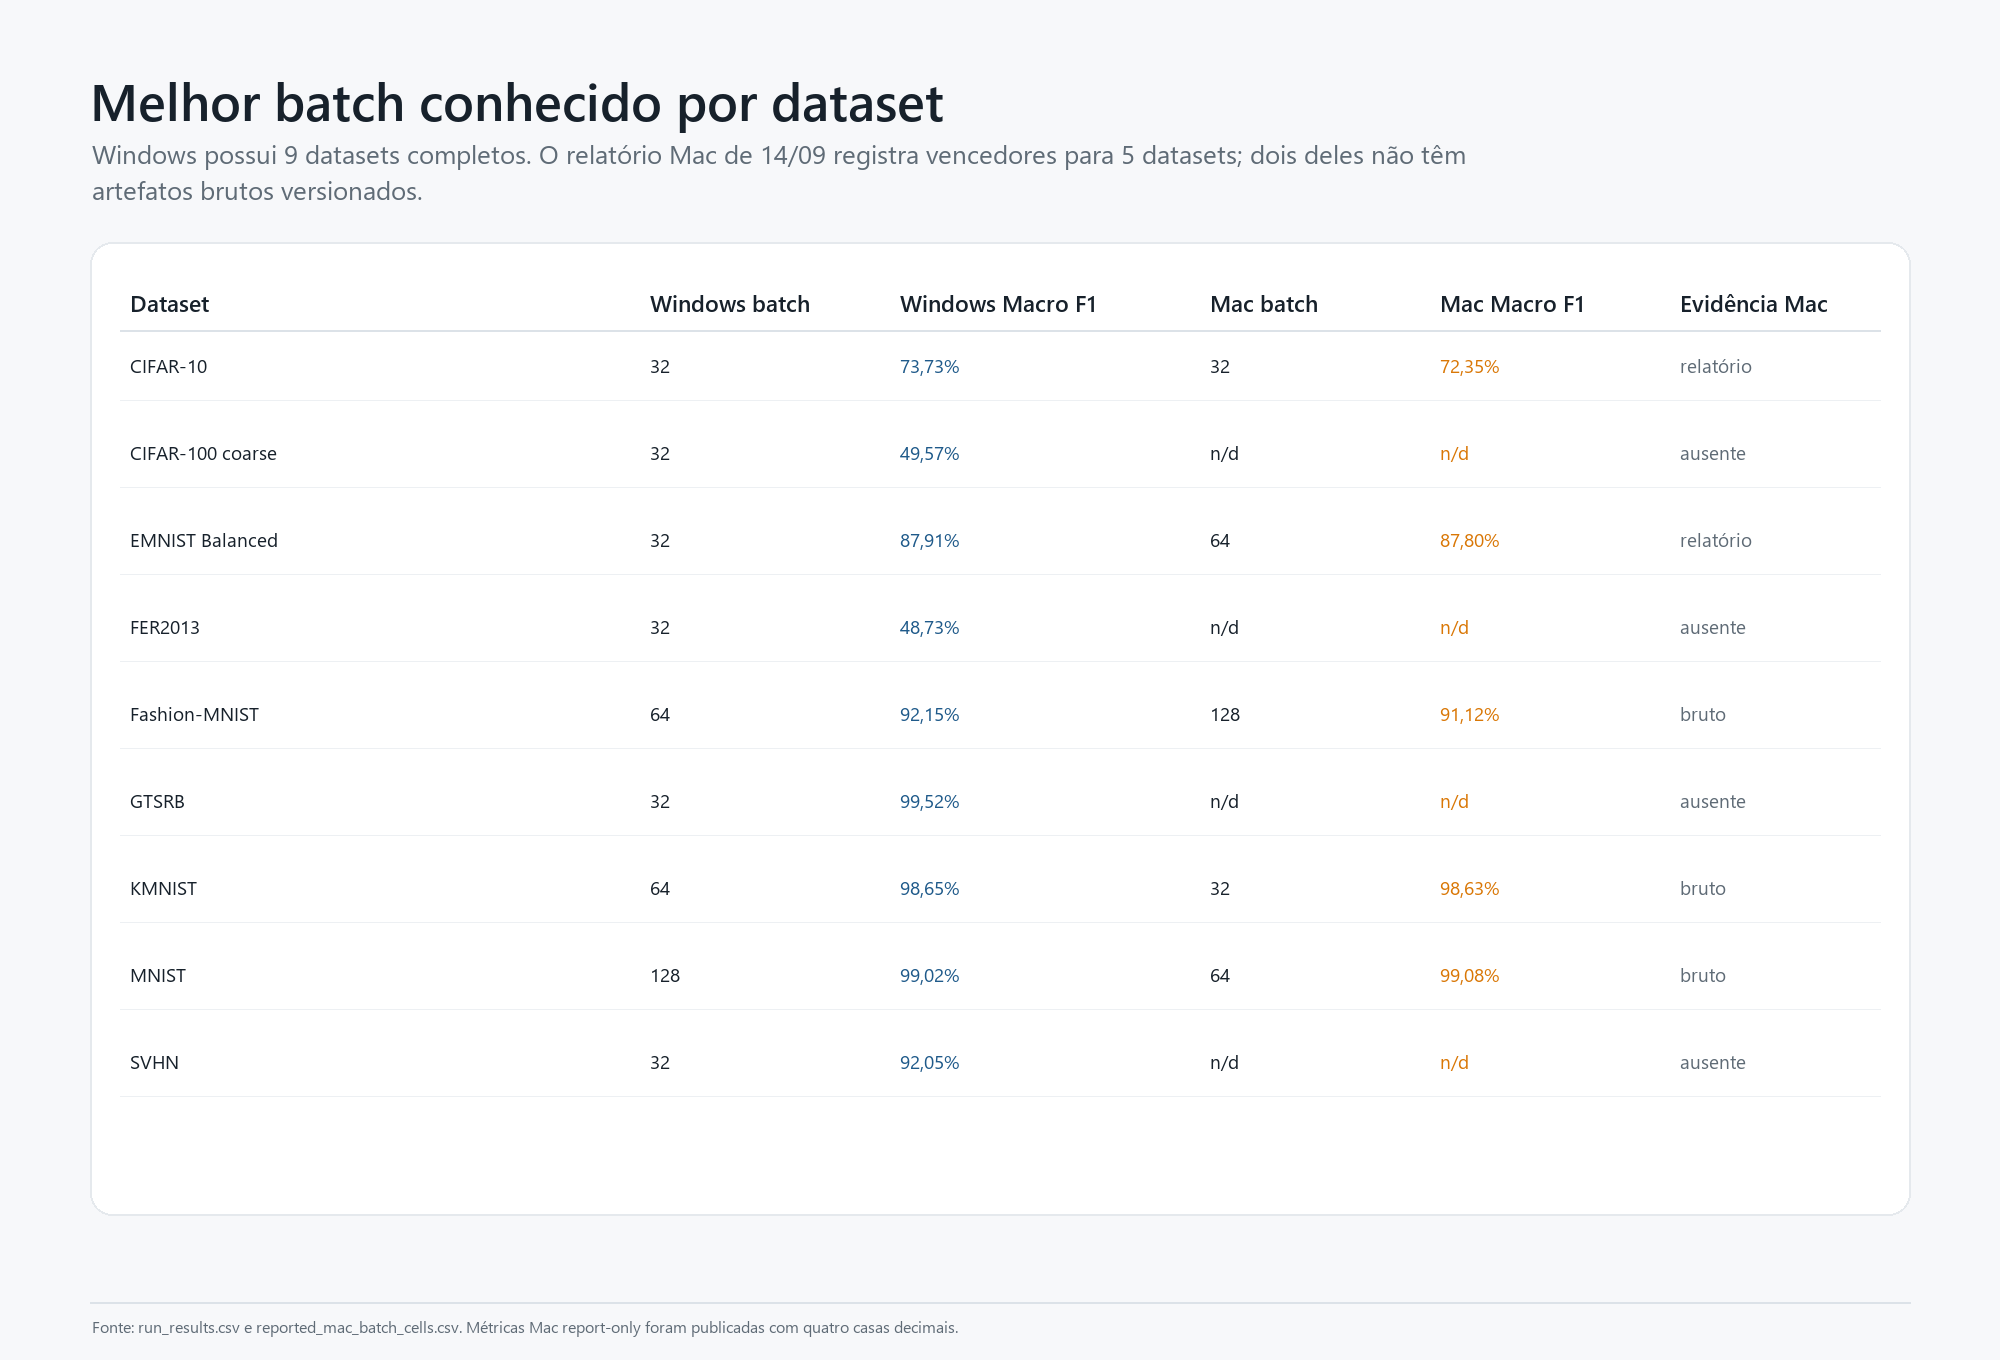

In [10]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / "13_melhores_batches_por_dataset.png")))


## 5. Comparação principal: seis pares batch equivalentes


Estes seis pares têm mesmo dataset, batch, fração adicional, seed e fingerprint de split. O Macro F1 médio difere apenas **+0.019 p.p.** (Windows − Mac), com mediana **-0.068 p.p.**. O Mac vence em Macro F1 em 4/6 pares e o Windows em 2/6.

Em desempenho computacional, o Windows foi mais rápido em todos os seis pares; a mediana de `tempo Windows / tempo Mac` foi **0.189**, isto é, o Windows consumiu cerca de 18,9% do tempo do Mac nesses pares. Isso não deve ser generalizado para arquiteturas ou stacks diferentes.


In [11]:
exact_columns = ["dataset","batch_size_windows","macro_f1_windows","macro_f1_mac","delta_macro_f1_pp_windows_minus_mac","accuracy_windows","accuracy_mac","loss_windows","loss_mac","mean_epoch_seconds_windows","mean_epoch_seconds_mac","epoch_time_ratio_windows_over_mac","macro_f1_winner","training_time_winner","same_split_fingerprint"]
exact_view = batch_pairs[exact_columns].sort_values(["dataset","batch_size_windows"])
exact_view


dataset,batch_size_windows,macro_f1_windows,macro_f1_mac,delta_macro_f1_pp_windows_minus_mac,accuracy_windows,accuracy_mac,loss_windows,loss_mac,mean_epoch_seconds_windows,mean_epoch_seconds_mac,epoch_time_ratio_windows_over_mac,macro_f1_winner,training_time_winner,same_split_fingerprint
Fashion-MNIST,128,0.915232,0.911170,0.406237,0.915619,0.911524,0.235719,0.246912,35.081800,233.247898,0.150406,Windows,Windows,True
Fashion-MNIST,256,0.907813,0.909732,-0.191940,0.908286,0.909905,0.255148,0.253685,26.121881,134.237933,0.194594,Mac,Windows,True
KMNIST,32,0.985804,0.986290,-0.048534,0.985810,0.986286,0.053608,0.057569,96.716817,616.046490,0.156996,Mac,Windows,True
MNIST,32,0.989468,0.988215,0.125337,0.989617,0.988379,0.033478,0.048391,97.034078,513.556422,0.188945,Windows,Windows,True
MNIST,64,0.989905,0.990785,-0.088035,0.989998,0.990855,0.041693,0.032575,56.363311,297.454864,0.189485,Mac,Windows,True
MNIST,256,0.989187,0.990069,-0.088247,0.989331,0.990189,0.035260,0.035219,26.731456,140.362874,0.190445,Mac,Windows,True


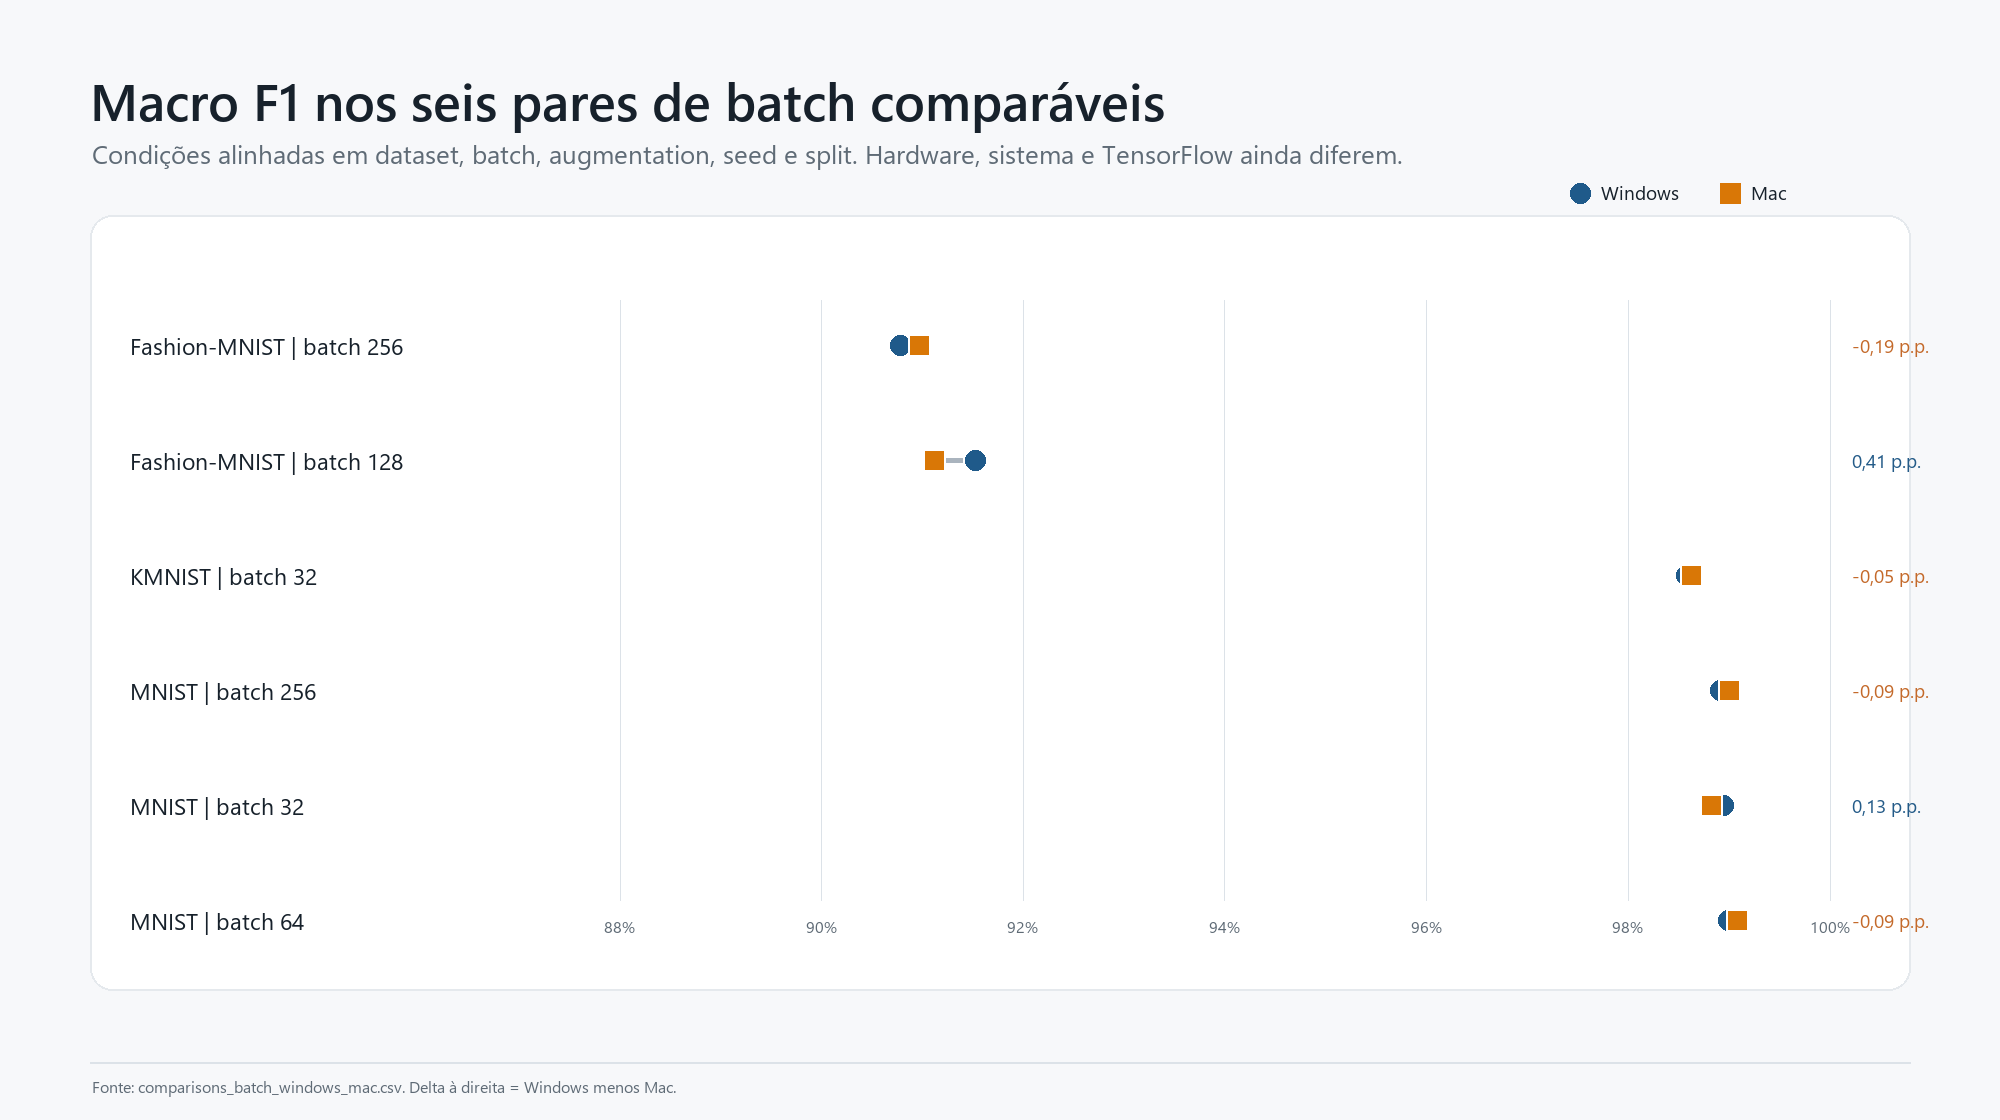

In [12]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / "05_macro_f1_pares_batch.png")))


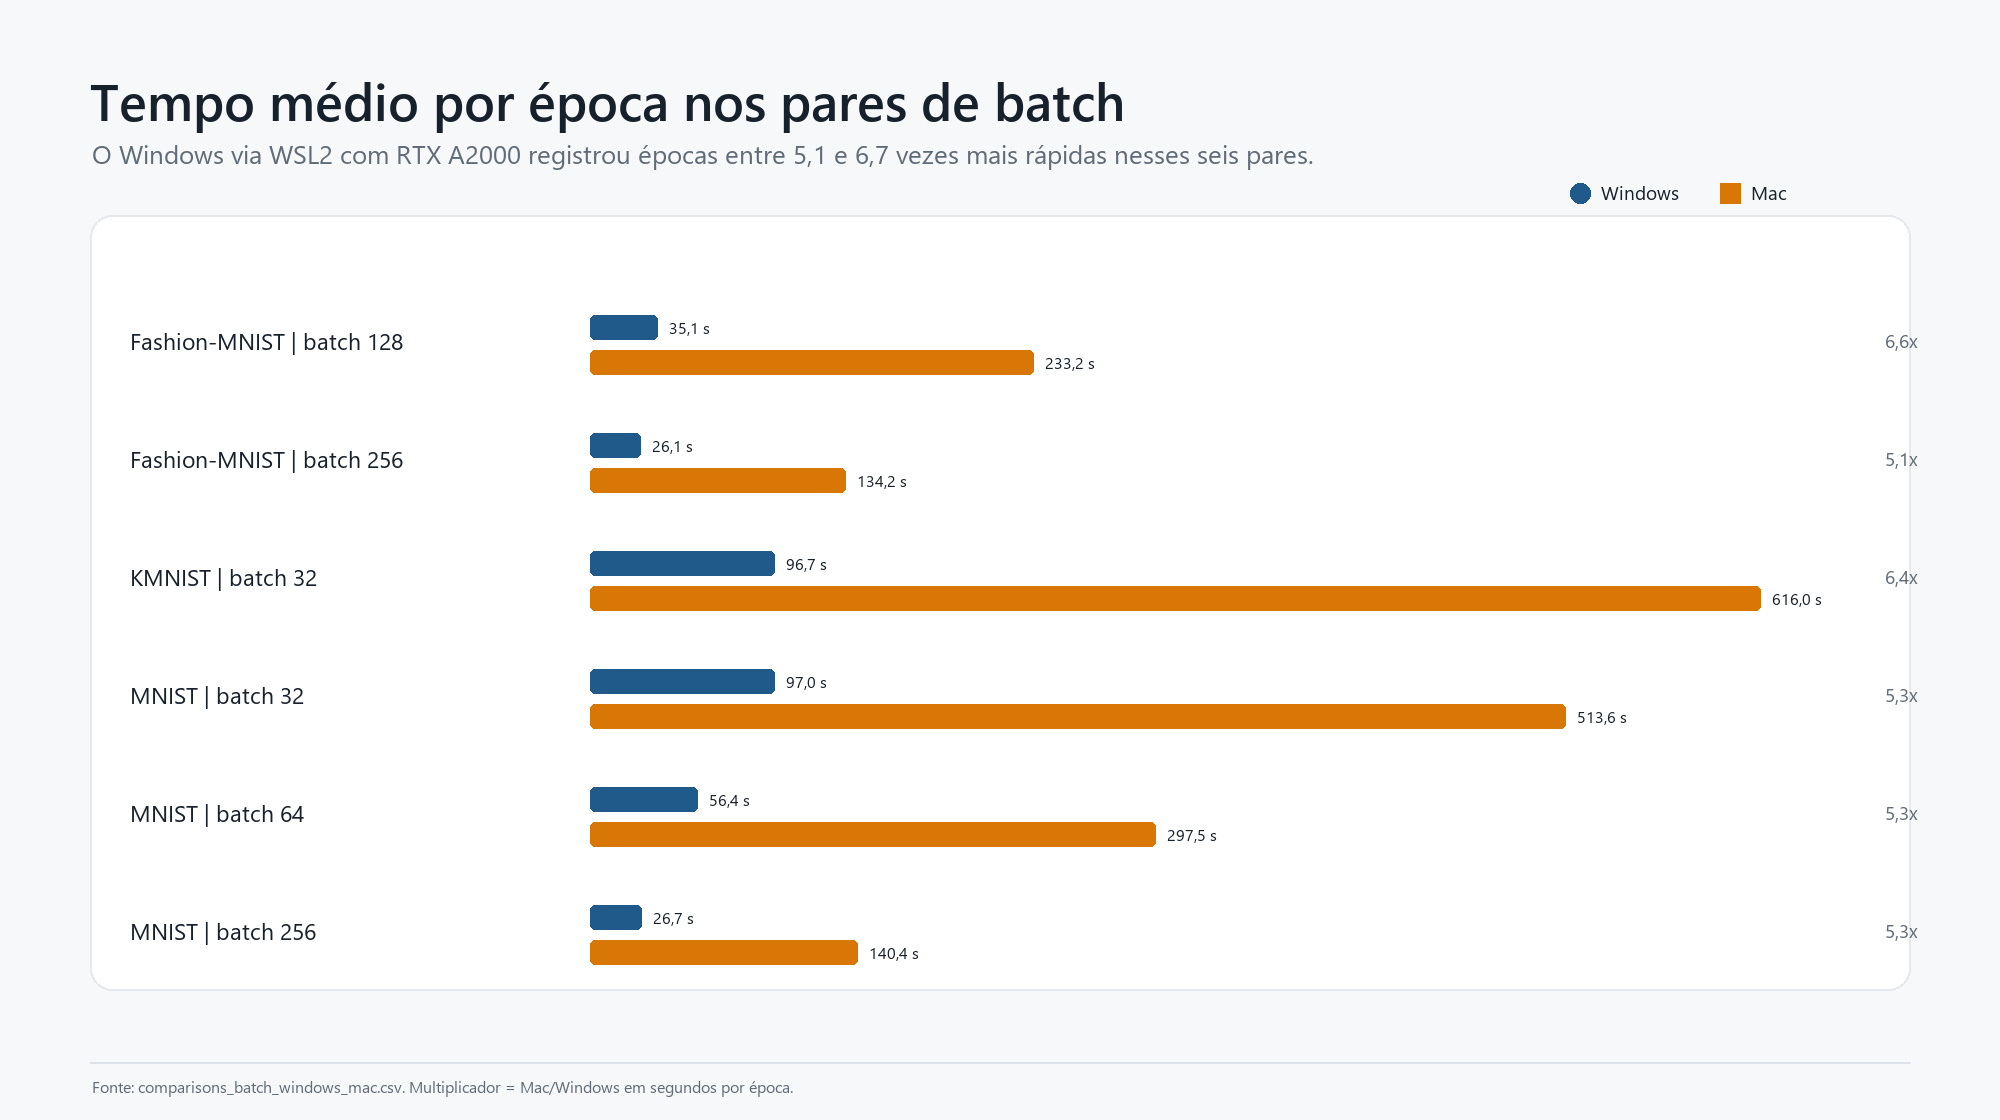

In [13]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / "06_tempo_epoca_pares_batch.png")))


## 6. Ativações: comparação descritiva em 21 pares


Há 21 pares por dataset e ativação. Eles **não isolam o sistema operacional**: Windows usa batches específicos por dataset e Mac usa batch 256; a versão do TensorFlow também difere. A diferença média descritiva de Macro F1 foi **+3.305 p.p.**.

As diferenças materiais concentram-se em ReLU e Sigmoid. Softmax como ativação oculta colapsou para desempenho próximo do acaso em ambos os ambientes e é empate numérico dentro da precisão prática.


In [14]:
activation_columns = ["dataset","activation","batch_size_windows","batch_size_mac","macro_f1_windows","macro_f1_mac","delta_macro_f1_pp_windows_minus_mac","accuracy_windows","accuracy_mac","loss_windows","loss_mac","mean_epoch_seconds_windows","mean_epoch_seconds_mac","comparability_grade"]
activation_view = activation_pairs[activation_columns].sort_values(["dataset","activation"])
activation_view


dataset,activation,batch_size_windows,batch_size_mac,macro_f1_windows,macro_f1_mac,delta_macro_f1_pp_windows_minus_mac,accuracy_windows,accuracy_mac,loss_windows,loss_mac,mean_epoch_seconds_windows,mean_epoch_seconds_mac,comparability_grade
CIFAR-10,relu,32,256,0.718656,0.564456,15.419974,0.718222,0.566444,0.823548,1.160675,78.132247,115.123336,B_descriptive_batch_mismatch
CIFAR-10,sigmoid,32,256,0.710131,0.638977,7.115371,0.714111,0.636667,0.832665,1.012245,91.479677,142.049362,B_descriptive_batch_mismatch
CIFAR-10,softmax,32,256,0.018182,0.018182,0.000000,0.100000,0.100000,2.302608,2.302591,90.943869,113.735643,B_descriptive_batch_mismatch
CIFAR-100 coarse,relu,32,256,0.443877,0.299782,14.409525,0.448556,0.303222,1.818286,2.257801,90.737327,114.203819,B_descriptive_batch_mismatch
CIFAR-100 coarse,sigmoid,32,256,0.463437,0.350154,11.328255,0.466556,0.366111,1.708419,2.052153,79.159578,142.135061,B_descriptive_batch_mismatch
CIFAR-100 coarse,softmax,32,256,0.004762,0.004762,0.000000,0.050000,0.050000,2.995753,2.995737,61.810258,115.713818,B_descriptive_batch_mismatch
EMNIST Balanced,relu,32,256,0.870623,0.844157,2.646618,0.872695,0.848632,0.363602,0.568742,121.628991,236.750569,B_descriptive_batch_mismatch
EMNIST Balanced,sigmoid,32,256,0.866123,0.849283,1.684004,0.867629,0.852786,0.378650,0.436212,183.284944,303.804290,B_descriptive_batch_mismatch
EMNIST Balanced,softmax,32,256,0.000887,0.000887,0.000000,0.021277,0.021277,3.850193,3.850156,184.227807,244.856882,B_descriptive_batch_mismatch
Fashion-MNIST,relu,64,256,0.917707,0.875010,4.269662,0.918286,0.878190,0.229352,0.327285,40.237052,117.864861,B_descriptive_batch_mismatch


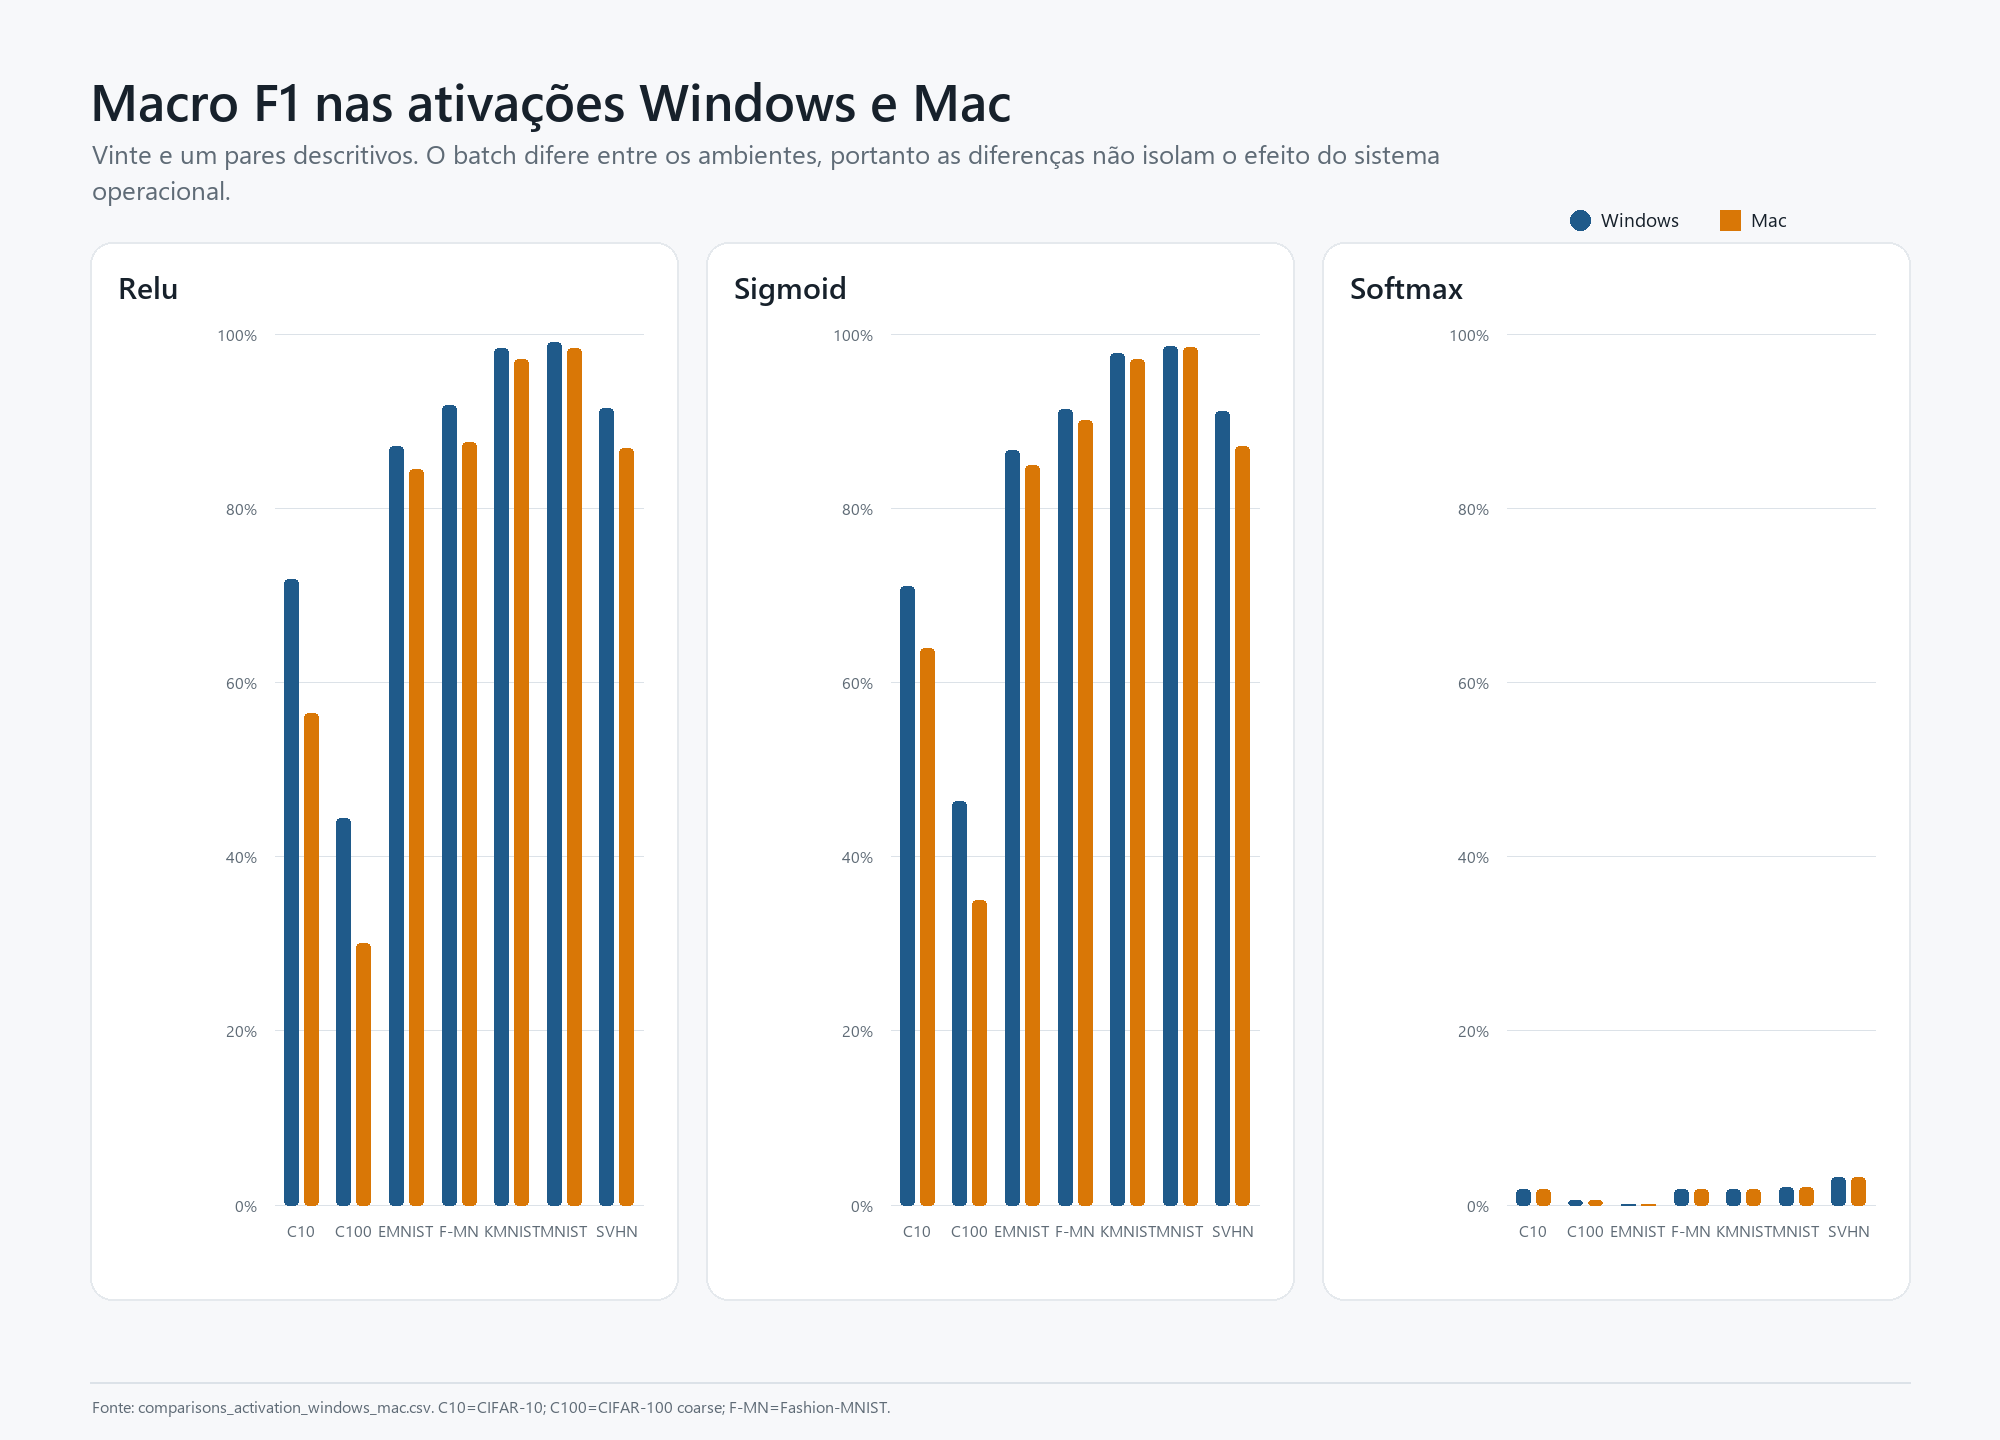

In [15]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / "03_macro_f1_ativacoes_windows_mac.png")))


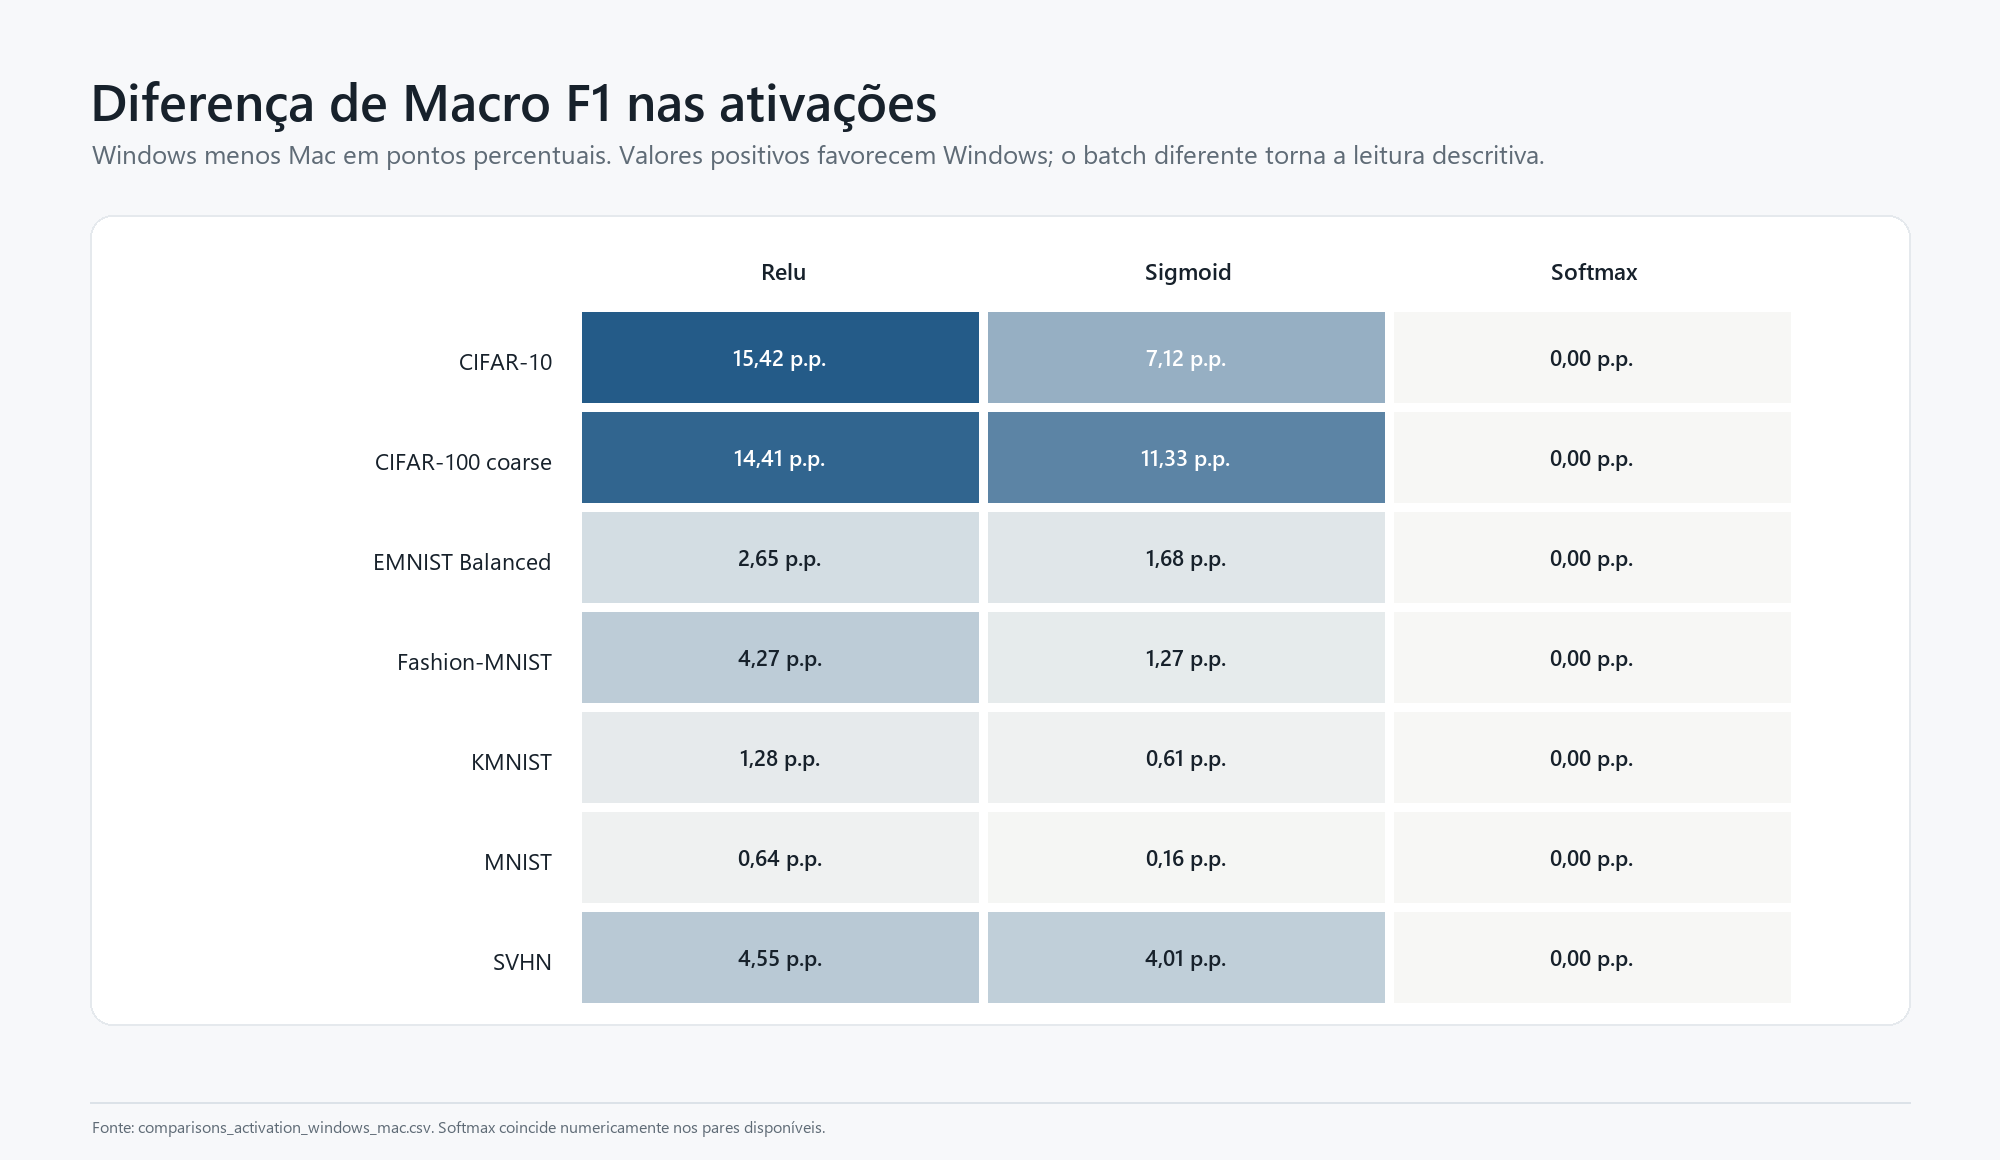

In [16]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / "04_delta_macro_f1_ativacoes_heatmap.png")))


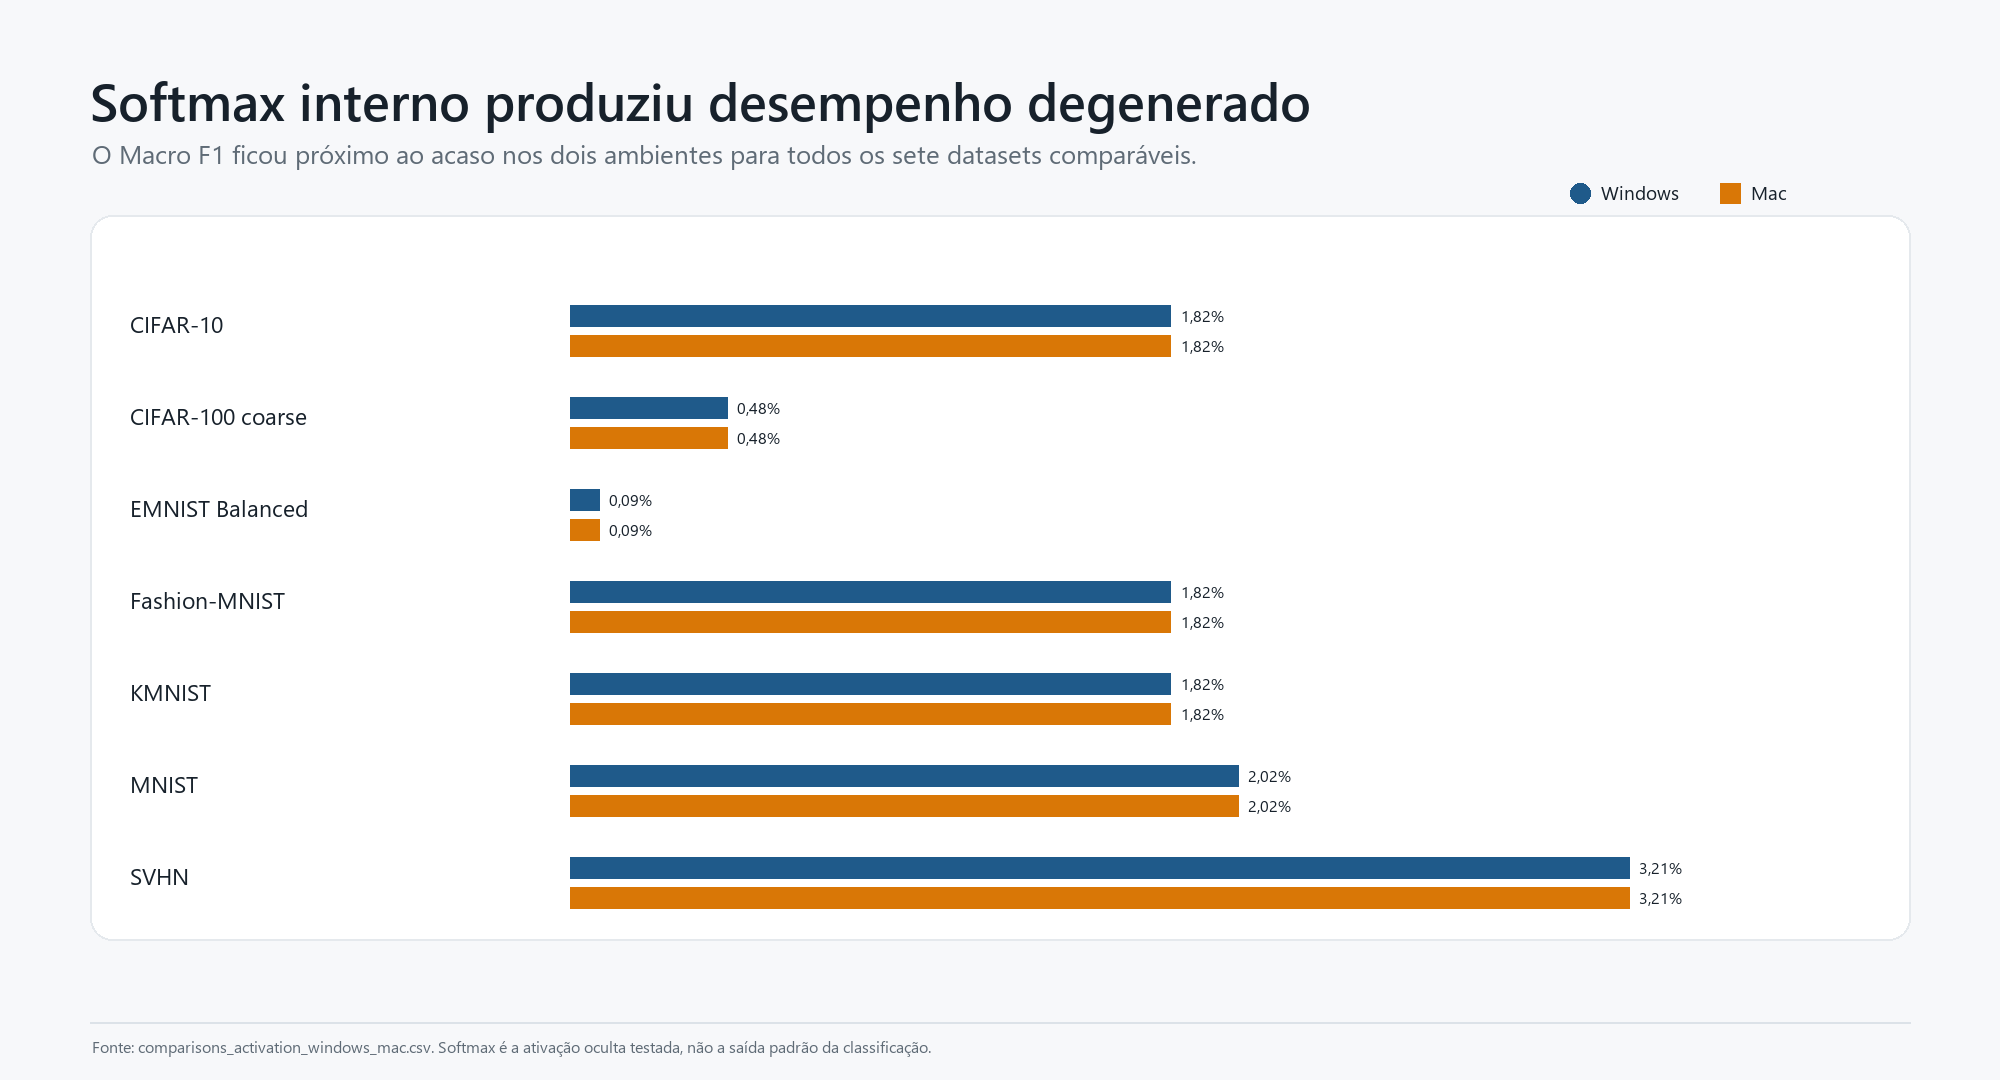

In [17]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / "12_softmax_macro_f1.png")))


## 7. Curvas, loss e tempo por epoch


As séries brutas de epoch estão disponíveis para 118 runs Windows e 15 runs Mac. A tabela resume o melhor Macro F1 de validação, menor `val_loss`, mediana de duração e throughput por run.


In [18]:
epoch_summary = (epochs.groupby(["platform","campaign","dataset","variant","run_uid"], dropna=False).agg(epochs=("epoch","count"), mediana_epoch_s=("epoch_seconds","median"), melhor_val_macro_f1=("val_macro_f1","max"), menor_val_loss=("val_loss","min"), media_examples_s=("train_examples_per_second","mean")).reset_index())
epoch_summary


platform,campaign,dataset,variant,run_uid,epochs,mediana_epoch_s,melhor_val_macro_f1,menor_val_loss,media_examples_s
Mac,controlled-augmentation2-mac-m4-aug05,CIFAR-10,smoke,mac|controlled-augmentation2-mac-m4-aug05|smoke|cifar10|smoke|seed-42|attempt-1,2,4.686671,0.023529,2.266199,64.065163
Mac,controlled-augmentation2-mac-m4-aug05,CIFAR-100 coarse,smoke,mac|controlled-augmentation2-mac-m4-aug05|smoke|cifar100-coarse|smoke|seed-42|attempt-1,2,5.921520,0.040422,2.983658,87.521205
Mac,controlled-augmentation2-mac-m4-aug05,EMNIST Balanced,smoke,mac|controlled-augmentation2-mac-m4-aug05|smoke|emnist-balanced|smoke|seed-42|attempt-1,2,9.700012,0.005241,3.817769,88.877362
Mac,controlled-augmentation2-mac-m4-aug05,FER2013,smoke,mac|controlled-augmentation2-mac-m4-aug05|smoke|fer2013|smoke|seed-42|attempt-1,2,4.220330,0.177489,1.941461,66.350194
Mac,controlled-augmentation2-mac-m4-aug05,Fashion-MNIST,batch-128,mac|controlled-augmentation2-mac-m4-aug05|batch|fashion-mnist|batch-128|seed-42|attempt-1,100,232.596517,0.918742,0.231742,315.179745
Mac,controlled-augmentation2-mac-m4-aug05,Fashion-MNIST,batch-256,mac|controlled-augmentation2-mac-m4-aug05|batch|fashion-mnist|batch-256|seed-42|attempt-1,100,134.090755,0.916113,0.239361,547.596149
Mac,controlled-augmentation2-mac-m4-aug05,Fashion-MNIST,smoke,mac|controlled-augmentation2-mac-m4-aug05|smoke|fashion-mnist|smoke|seed-42|attempt-1,2,4.592950,0.217857,2.172193,65.730558
Mac,controlled-augmentation2-mac-m4-aug05,GTSRB,smoke,mac|controlled-augmentation2-mac-m4-aug05|smoke|gtsrb|smoke|seed-42|attempt-1,2,10.518698,0.020360,3.743551,75.380282
Mac,controlled-augmentation2-mac-m4-aug05,KMNIST,batch-032,mac|controlled-augmentation2-mac-m4-aug05|batch|kmnist|batch-032|seed-42|attempt-1,100,615.241553,0.987805,0.047087,119.312531
Mac,controlled-augmentation2-mac-m4-aug05,KMNIST,smoke,mac|controlled-augmentation2-mac-m4-aug05|smoke|kmnist|smoke|seed-42|attempt-1,2,4.555953,0.140000,2.234552,68.638122


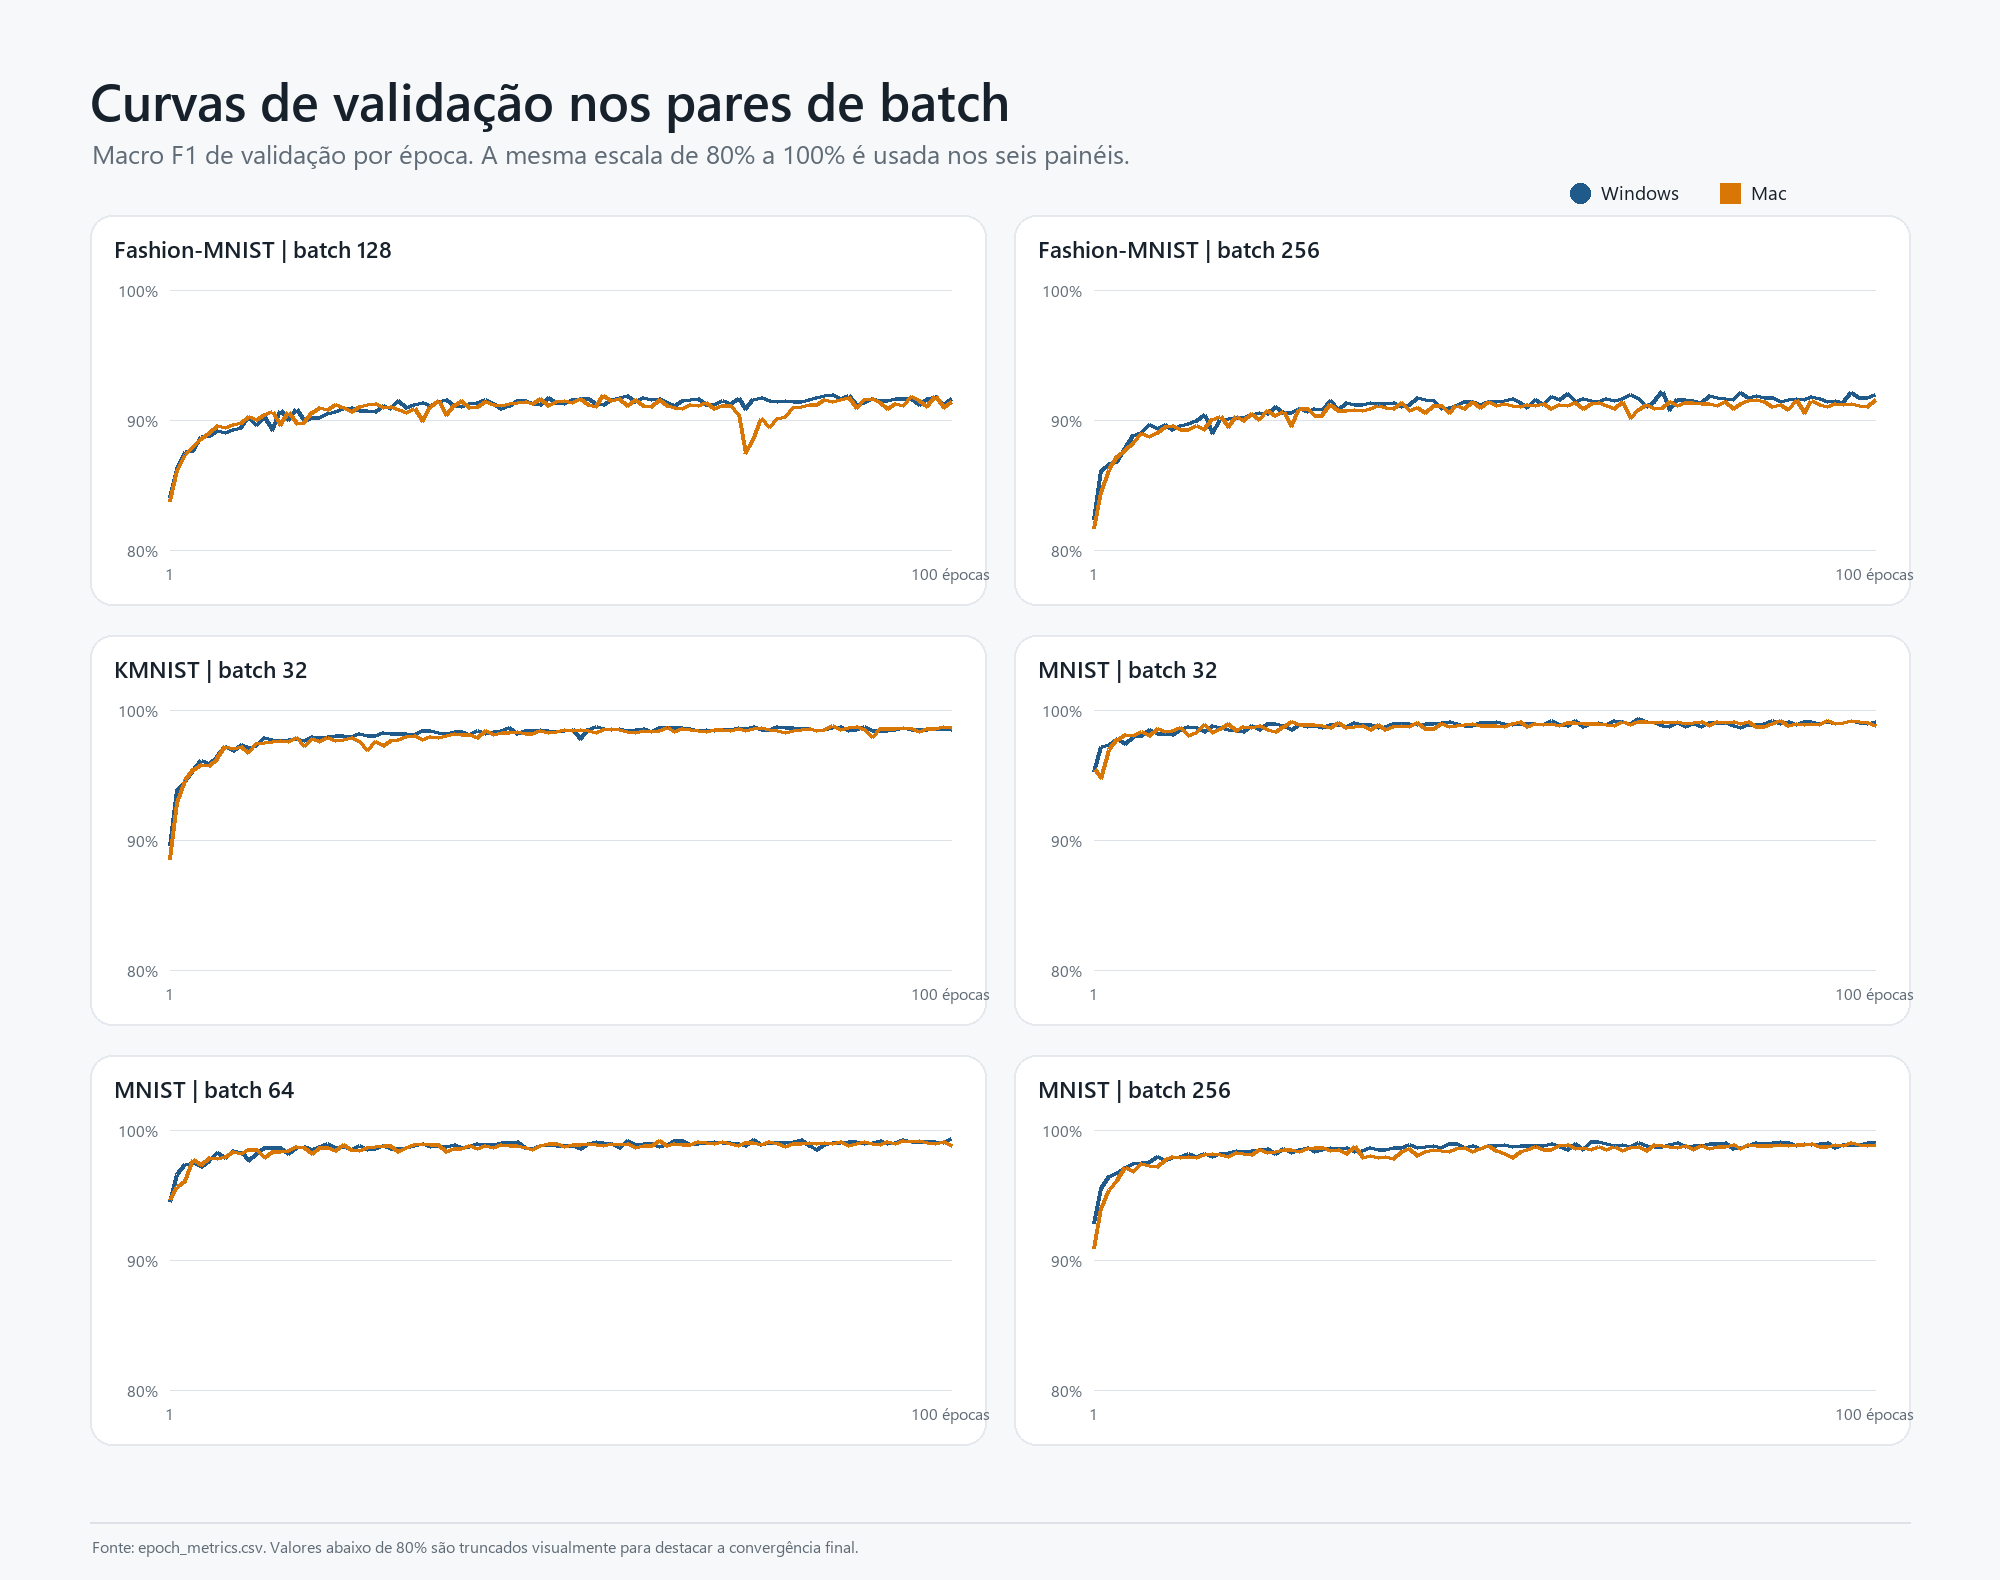

In [19]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / "08_curvas_validacao_pares_batch.png")))


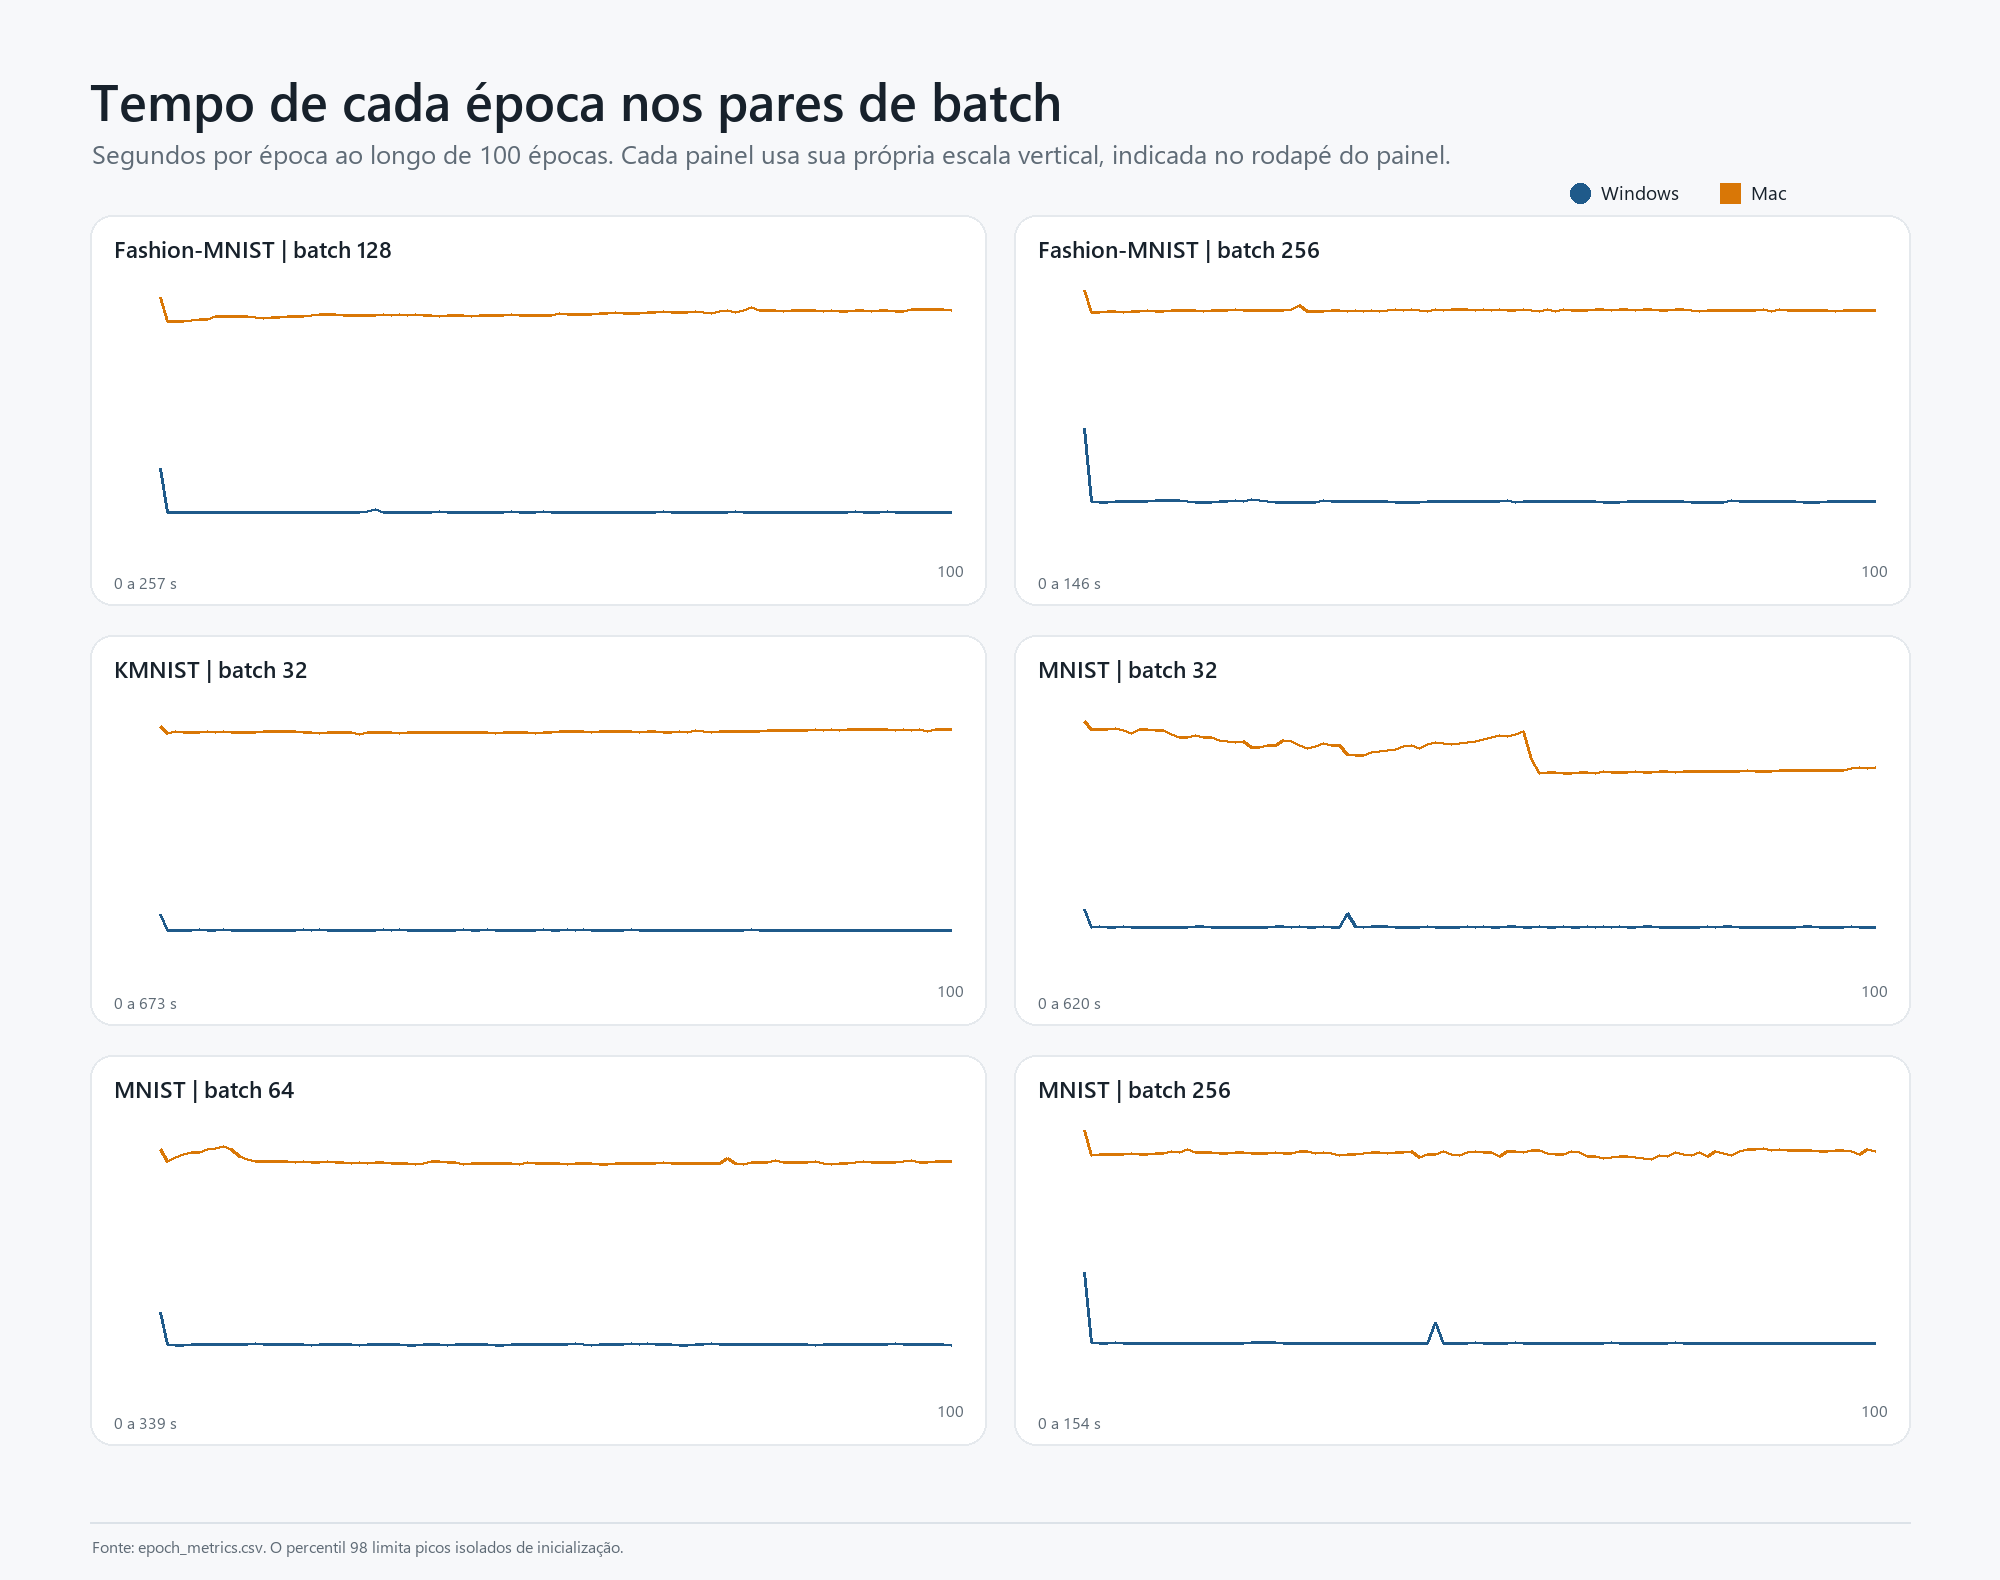

In [20]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / "09_tempo_por_epoca_pares_batch.png")))


## 8. Telemetria de hardware


Os campos de GPU não são semanticamente idênticos entre CUDA/NVML e Apple Metal; por isso, a utilização é comparada como sinal operacional e não como benchmark absoluto entre APIs. Memória é exibida em GiB.


In [21]:
telemetry_columns = ["dataset","batch_size_windows","gpu_util_pct_mean_windows","gpu_util_pct_mean_mac","gpu_memory_used_bytes_mean_windows","gpu_memory_used_bytes_mean_mac","process_cpu_pct_mean_windows","process_cpu_pct_mean_mac","ram_pct_mean_windows","ram_pct_mean_mac"]
telemetry_exact = batch_pairs[telemetry_columns].copy()
for column in [c for c in telemetry_exact if "bytes" in c]:
    telemetry_exact[column] = telemetry_exact[column] / (1024**3)
    telemetry_exact.rename(columns={column: column.replace("bytes", "gib")}, inplace=True)
telemetry_exact


dataset,batch_size_windows,gpu_util_pct_mean_windows,gpu_util_pct_mean_mac,gpu_memory_used_gib_mean_windows,gpu_memory_used_gib_mean_mac,process_cpu_pct_mean_windows,process_cpu_pct_mean_mac,ram_pct_mean_windows,ram_pct_mean_mac
Fashion-MNIST,128,32.638009,84.361178,1.751953,0.487326,102.947851,72.400484,20.819683,74.277946
Fashion-MNIST,256,35.097489,83.421107,2.006265,0.754012,88.135451,81.693545,20.707829,68.751605
KMNIST,32,34.959965,76.002722,1.635947,0.433684,117.030048,83.519476,20.516982,79.906992
MNIST,32,35.163508,67.635975,1.633341,0.348971,115.624460,94.385432,20.398898,77.394119
MNIST,64,33.334559,73.252594,1.632945,0.392552,110.857132,91.913989,20.692206,71.370874
MNIST,256,34.809869,83.107367,2.013060,0.705361,90.962990,85.105154,20.989550,71.696796


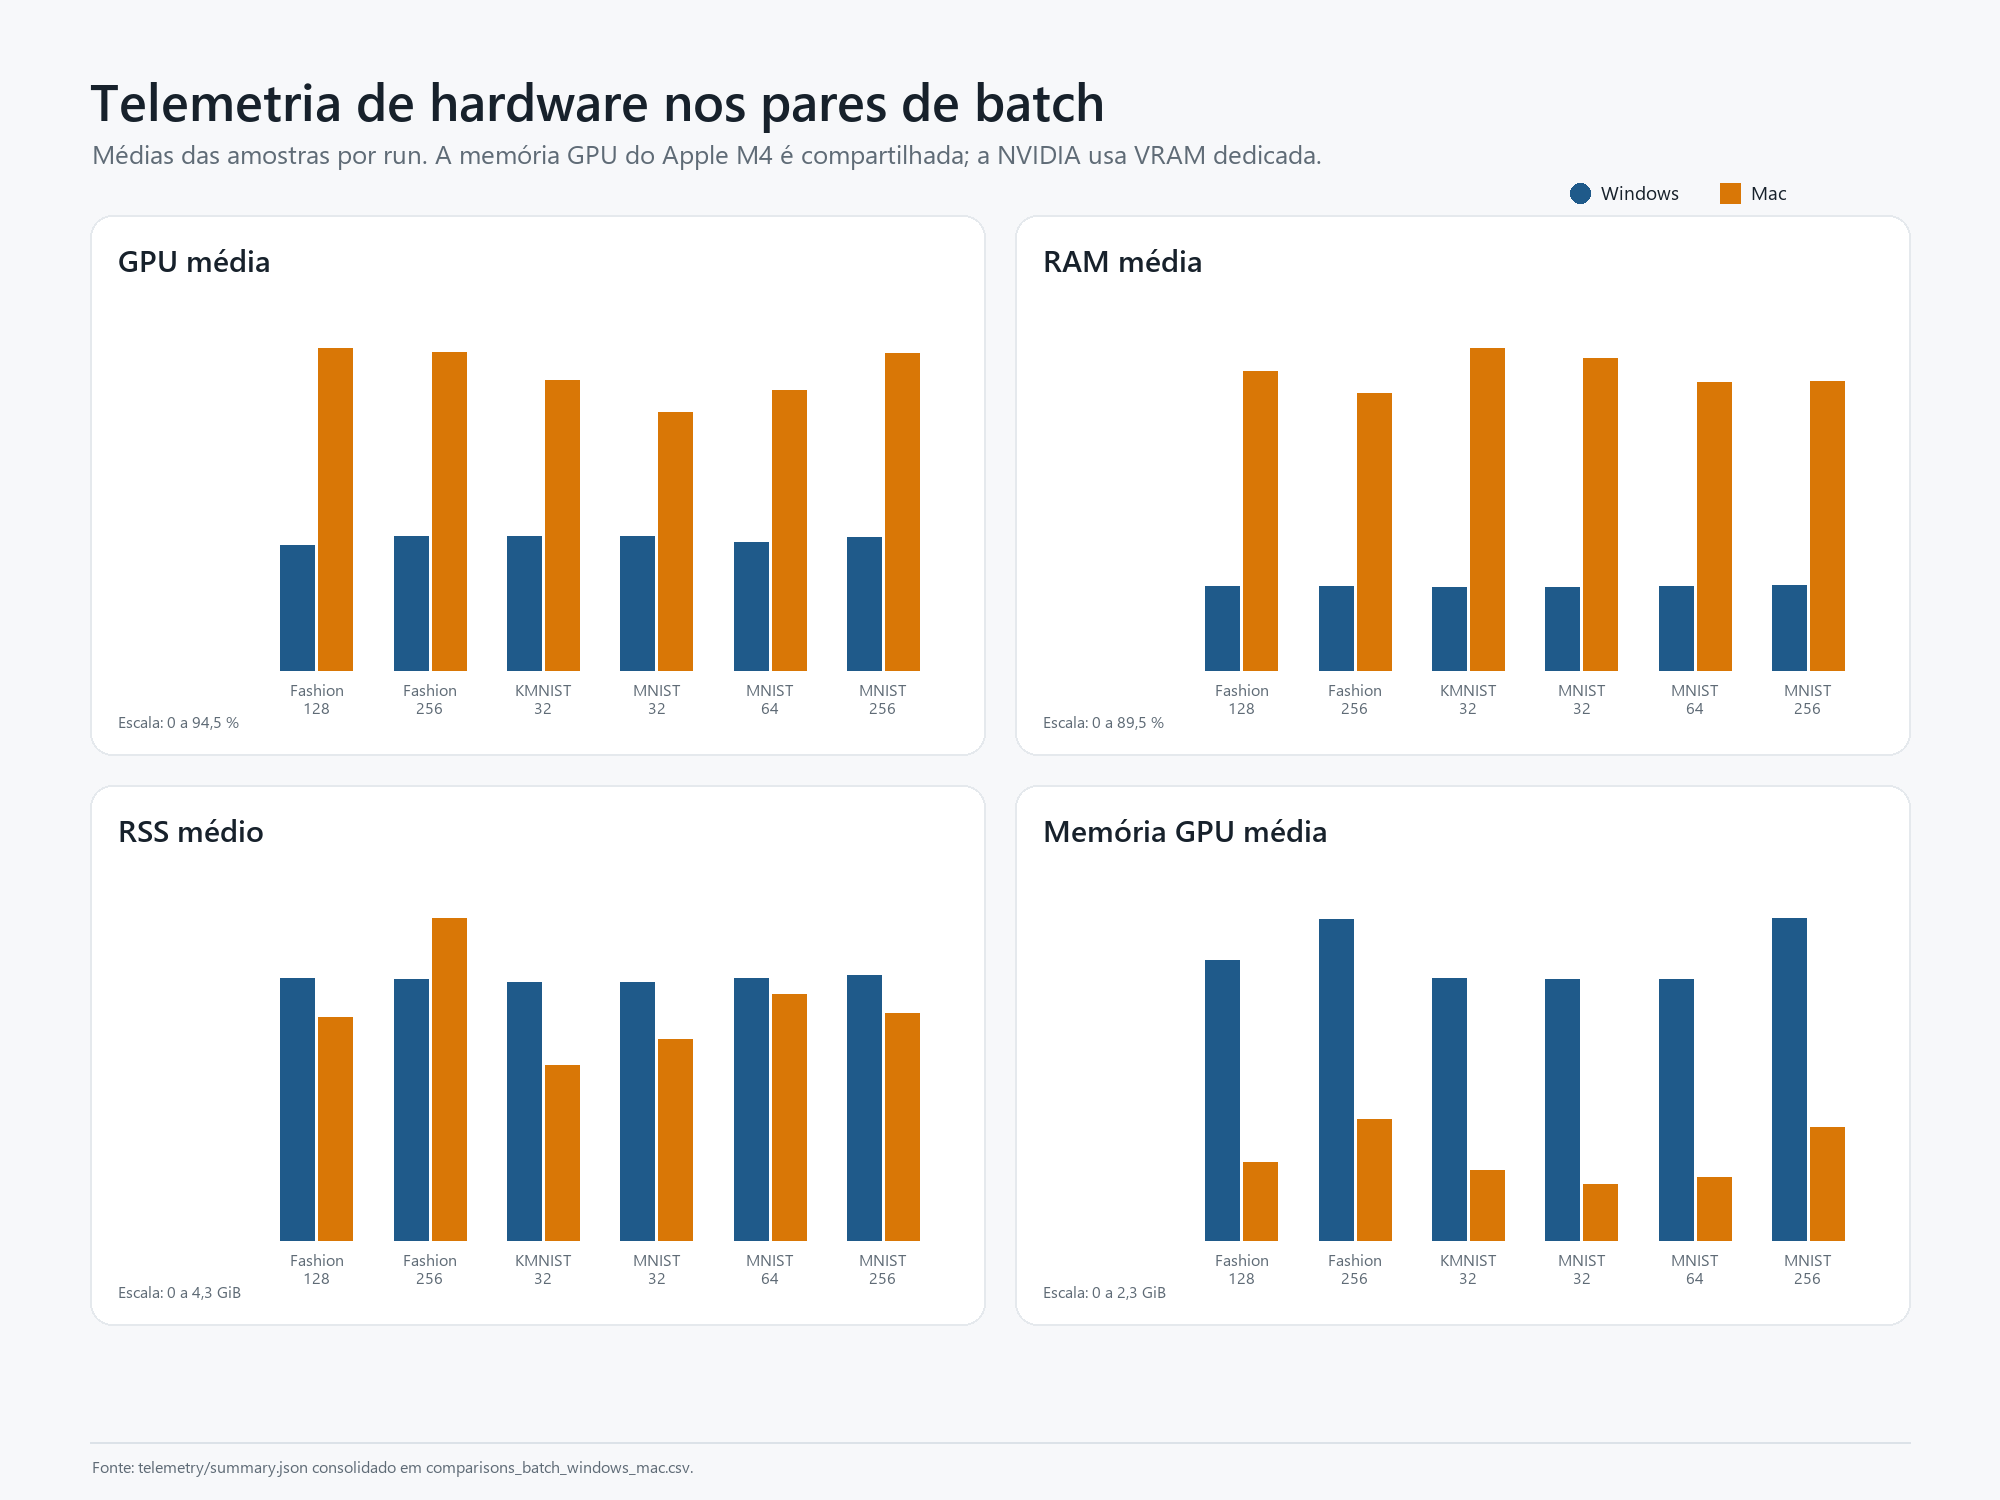

In [22]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / "07_telemetria_pares_batch.png")))


## 9. Métricas por classe


Foram consolidadas **2,307 linhas de classe**. A tabela seguinte mostra as 40 maiores diferenças absolutas de F1 por classe nos pares batch equivalentes. O sinal positivo favorece Windows; negativo favorece Mac. A tabela completa permanece em `class_metrics.csv`.


In [23]:
class_delta_parts = []
for _, pair in batch_pairs.iterrows():
    w = classes[classes.run_uid == pair.windows_run_uid][["class_index","class_name","support","precision","recall","f1"]].rename(columns={"class_name":"class_name_windows","support":"support_windows","precision":"precision_windows","recall":"recall_windows","f1":"f1_windows"})
    m = classes[classes.run_uid == pair.mac_run_uid][["class_index","class_name","support","precision","recall","f1"]].rename(columns={"class_name":"class_name_mac","support":"support_mac","precision":"precision_mac","recall":"recall_mac","f1":"f1_mac"})
    merged = w.merge(m, on="class_index", how="inner")
    merged.insert(0, "dataset", pair.dataset)
    merged.insert(1, "batch_size", int(pair.batch_size_windows))
    merged["class_name"] = merged.class_name_windows.fillna(merged.class_name_mac)
    merged["delta_f1_pp_windows_minus_mac"] = (merged.f1_windows - merged.f1_mac) * 100
    merged["abs_delta_f1_pp"] = merged.delta_f1_pp_windows_minus_mac.abs()
    class_delta_parts.append(merged)
class_deltas = pd.concat(class_delta_parts, ignore_index=True)
class_delta_view = class_deltas.sort_values("abs_delta_f1_pp", ascending=False)[["dataset","batch_size","class_index","class_name","support_windows","support_mac","f1_windows","f1_mac","delta_f1_pp_windows_minus_mac"]].head(40)
class_delta_view


dataset,batch_size,class_index,class_name,support_windows,support_mac,f1_windows,f1_mac,delta_f1_pp_windows_minus_mac
Fashion-MNIST,128,4,4,1050,1050,0.861758,0.848372,1.338563
Fashion-MNIST,128,6,6,1050,1050,0.779644,0.766337,1.330764
Fashion-MNIST,128,2,2,1050,1050,0.861004,0.850964,1.004006
Fashion-MNIST,256,6,6,1050,1050,0.752386,0.762224,-0.983862
Fashion-MNIST,128,0,0,1050,1050,0.868275,0.858644,0.963084
Fashion-MNIST,256,3,3,1050,1050,0.904200,0.913649,-0.944893
Fashion-MNIST,128,7,7,1050,1050,0.953566,0.962648,-0.908145
Fashion-MNIST,256,4,4,1050,1050,0.852830,0.844380,0.844979
MNIST,256,5,5,947,947,0.979701,0.985767,-0.606615
MNIST,64,5,5,947,947,0.981452,0.986793,-0.534141


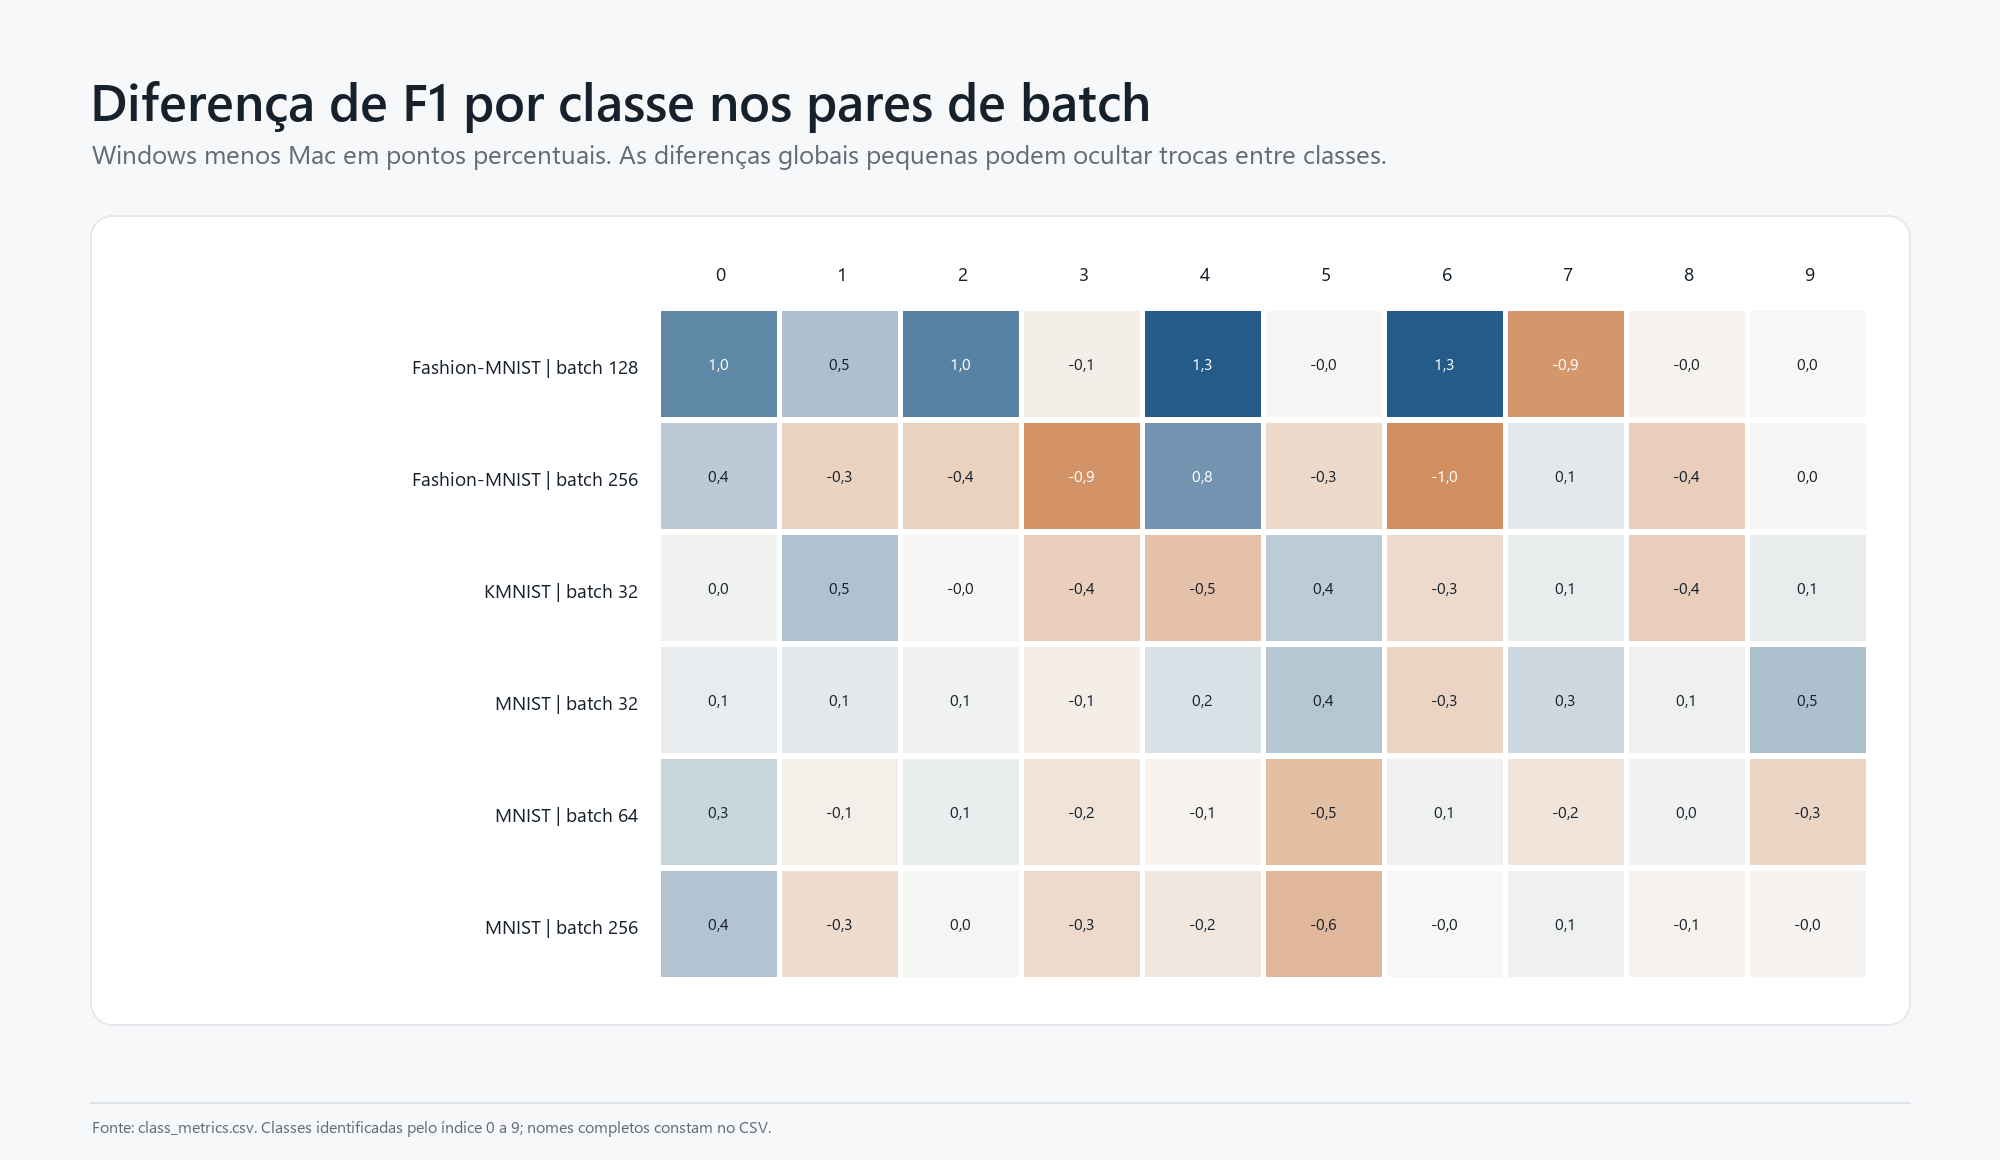

In [24]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / "10_delta_f1_por_classe_batch.png")))


## 10. Matrizes de confusão dos pares equivalentes


As matrizes abaixo usam a mesma escala dentro de cada par. Os totais foram validados contra o número de amostras de teste.


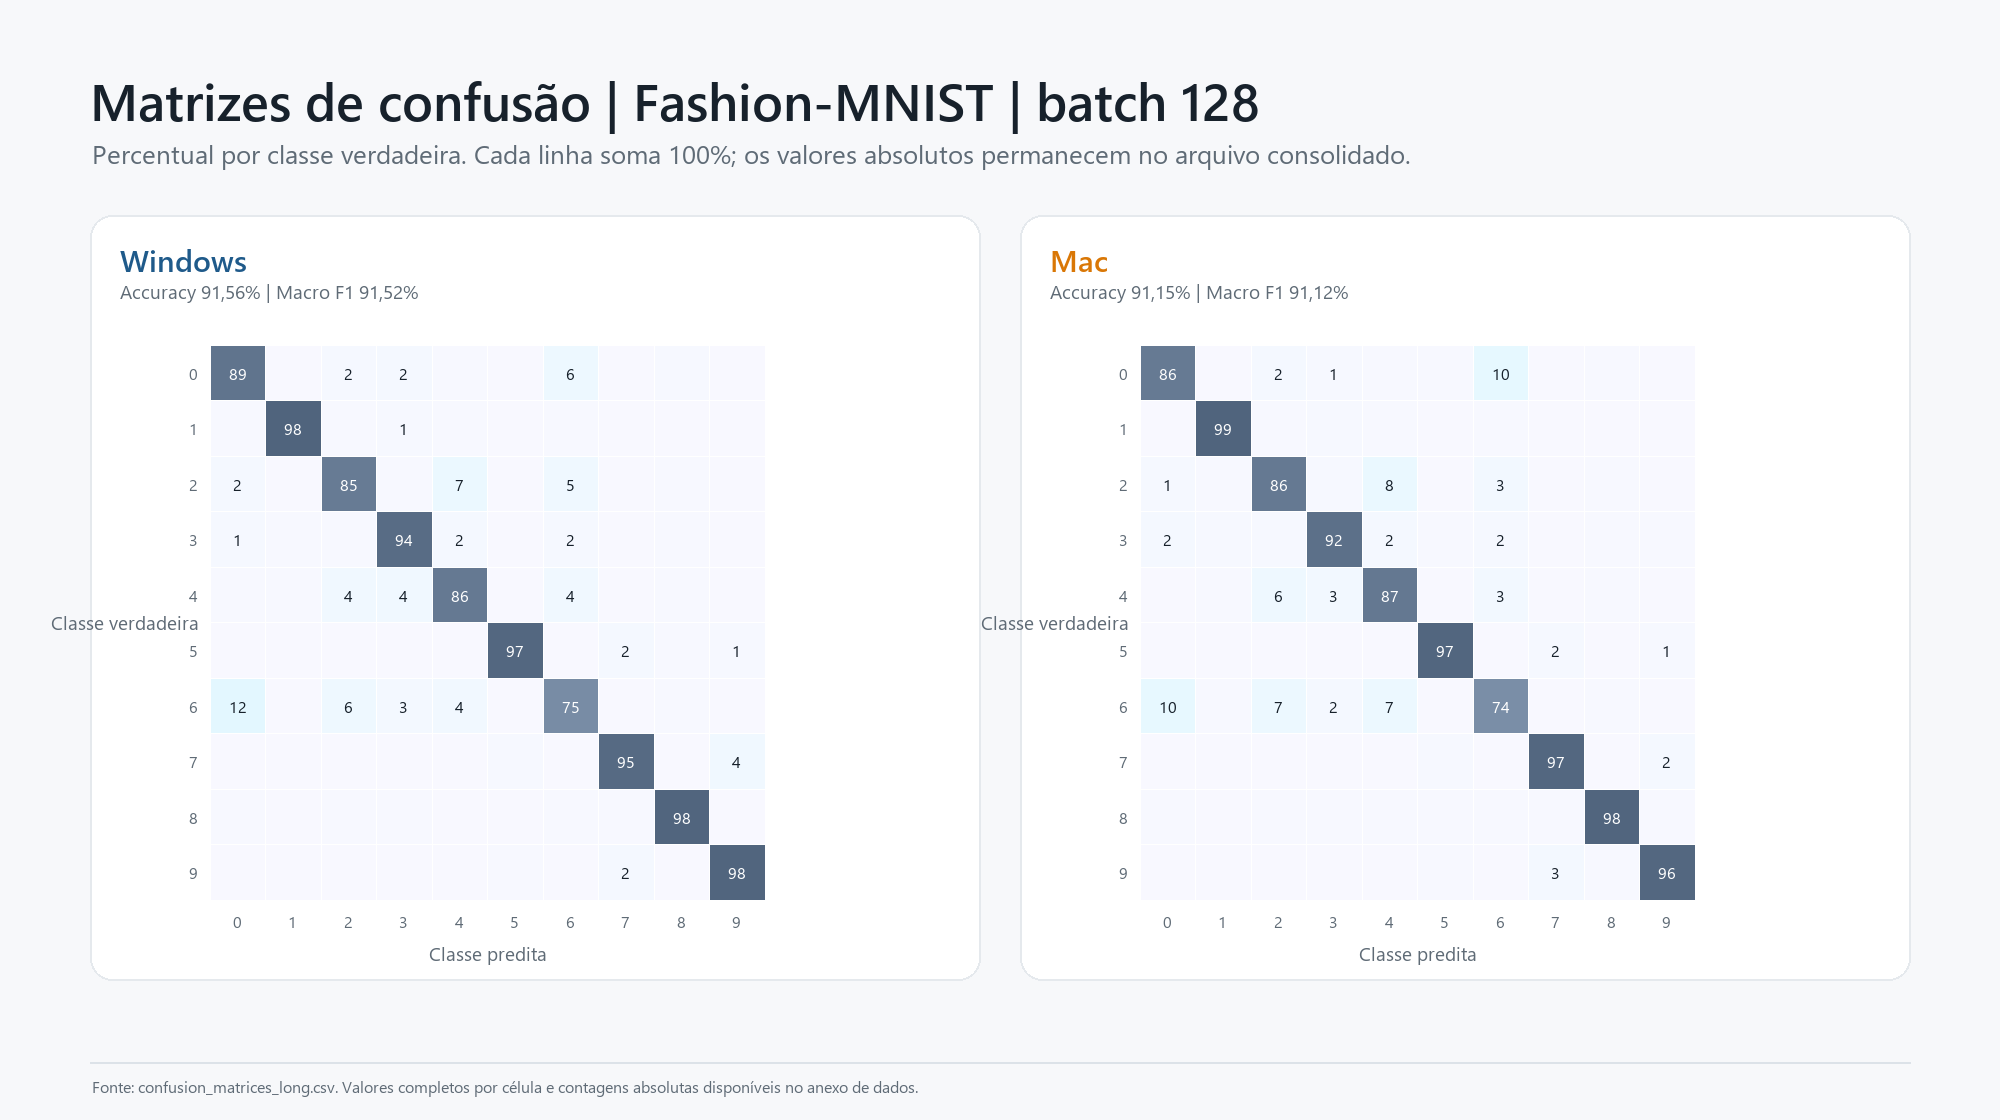

In [25]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / "11_01_matriz_confusao_fashion_mnist_batch_128.png")))


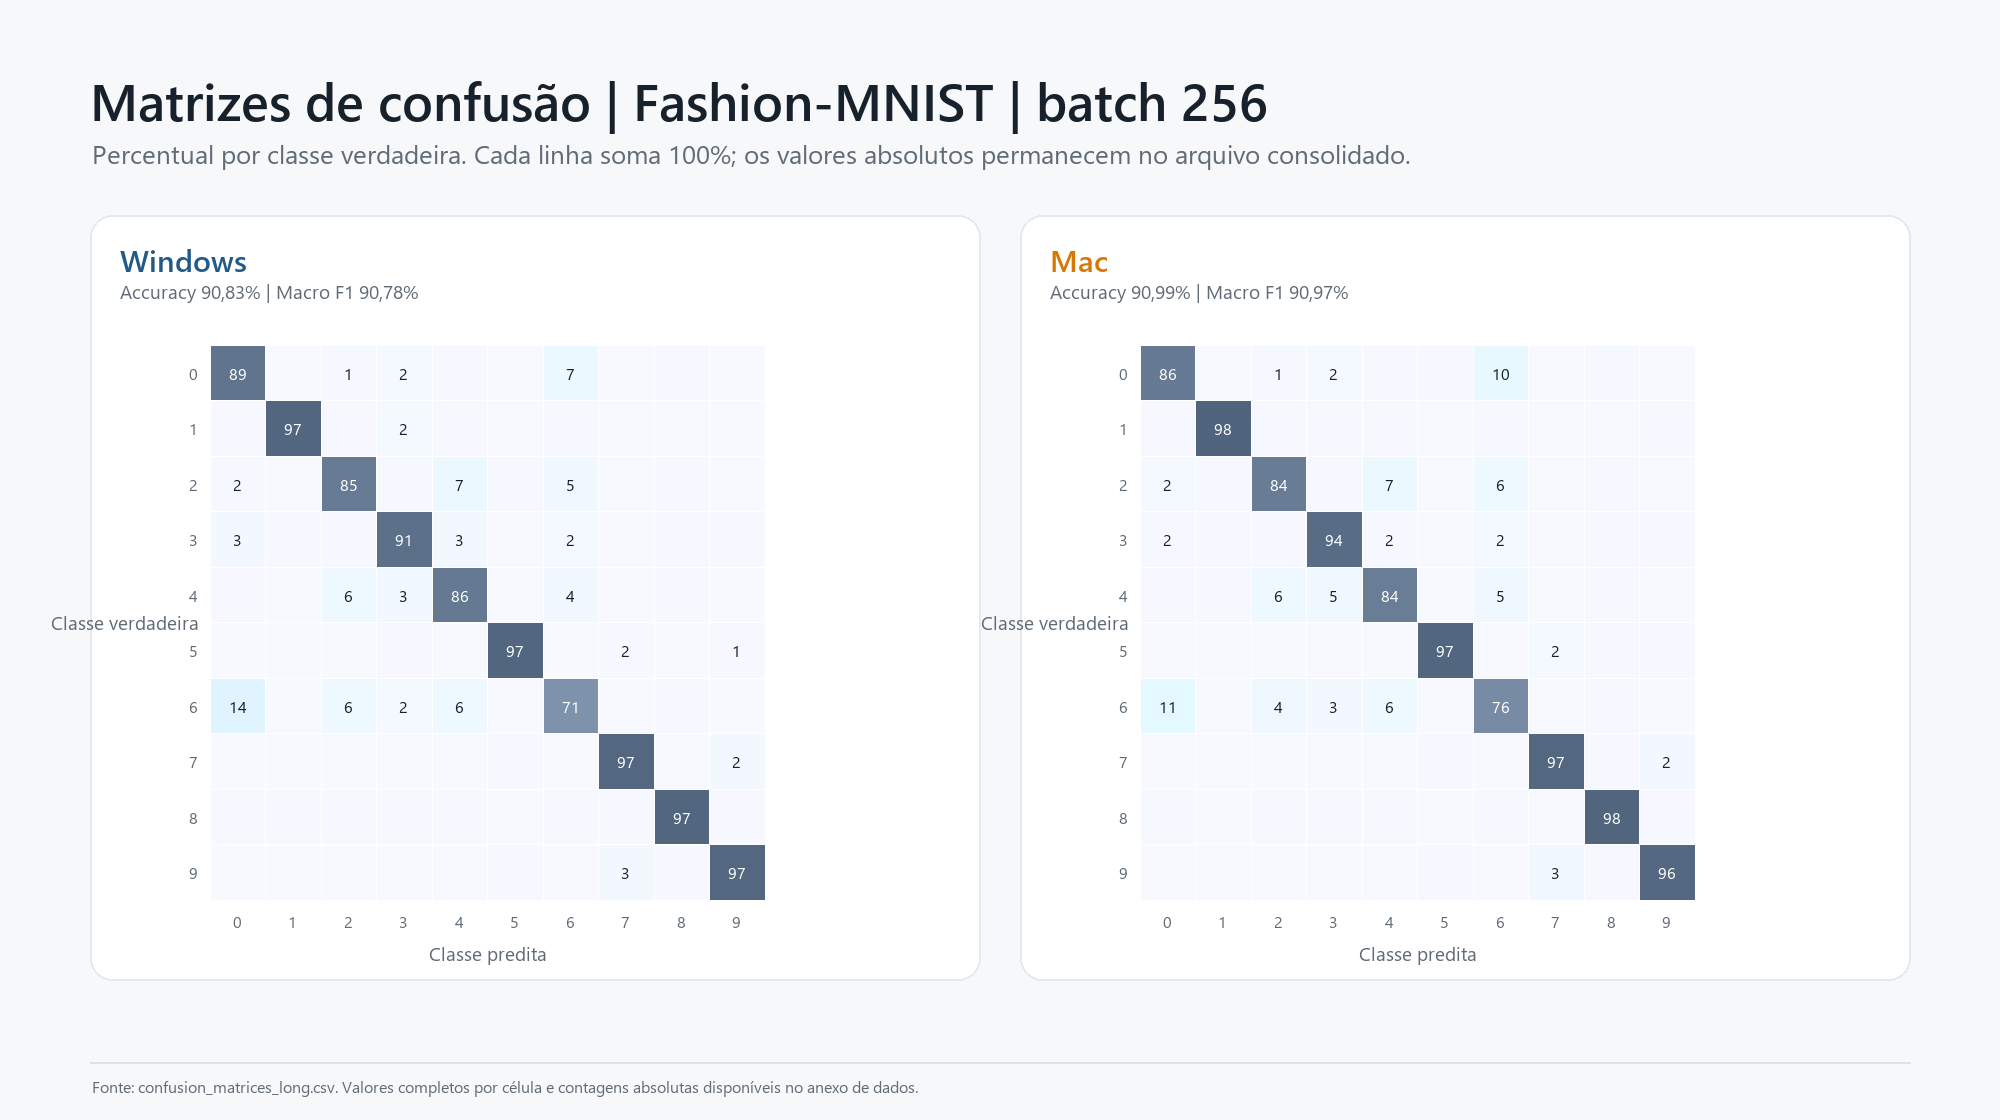

In [26]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / "11_02_matriz_confusao_fashion_mnist_batch_256.png")))


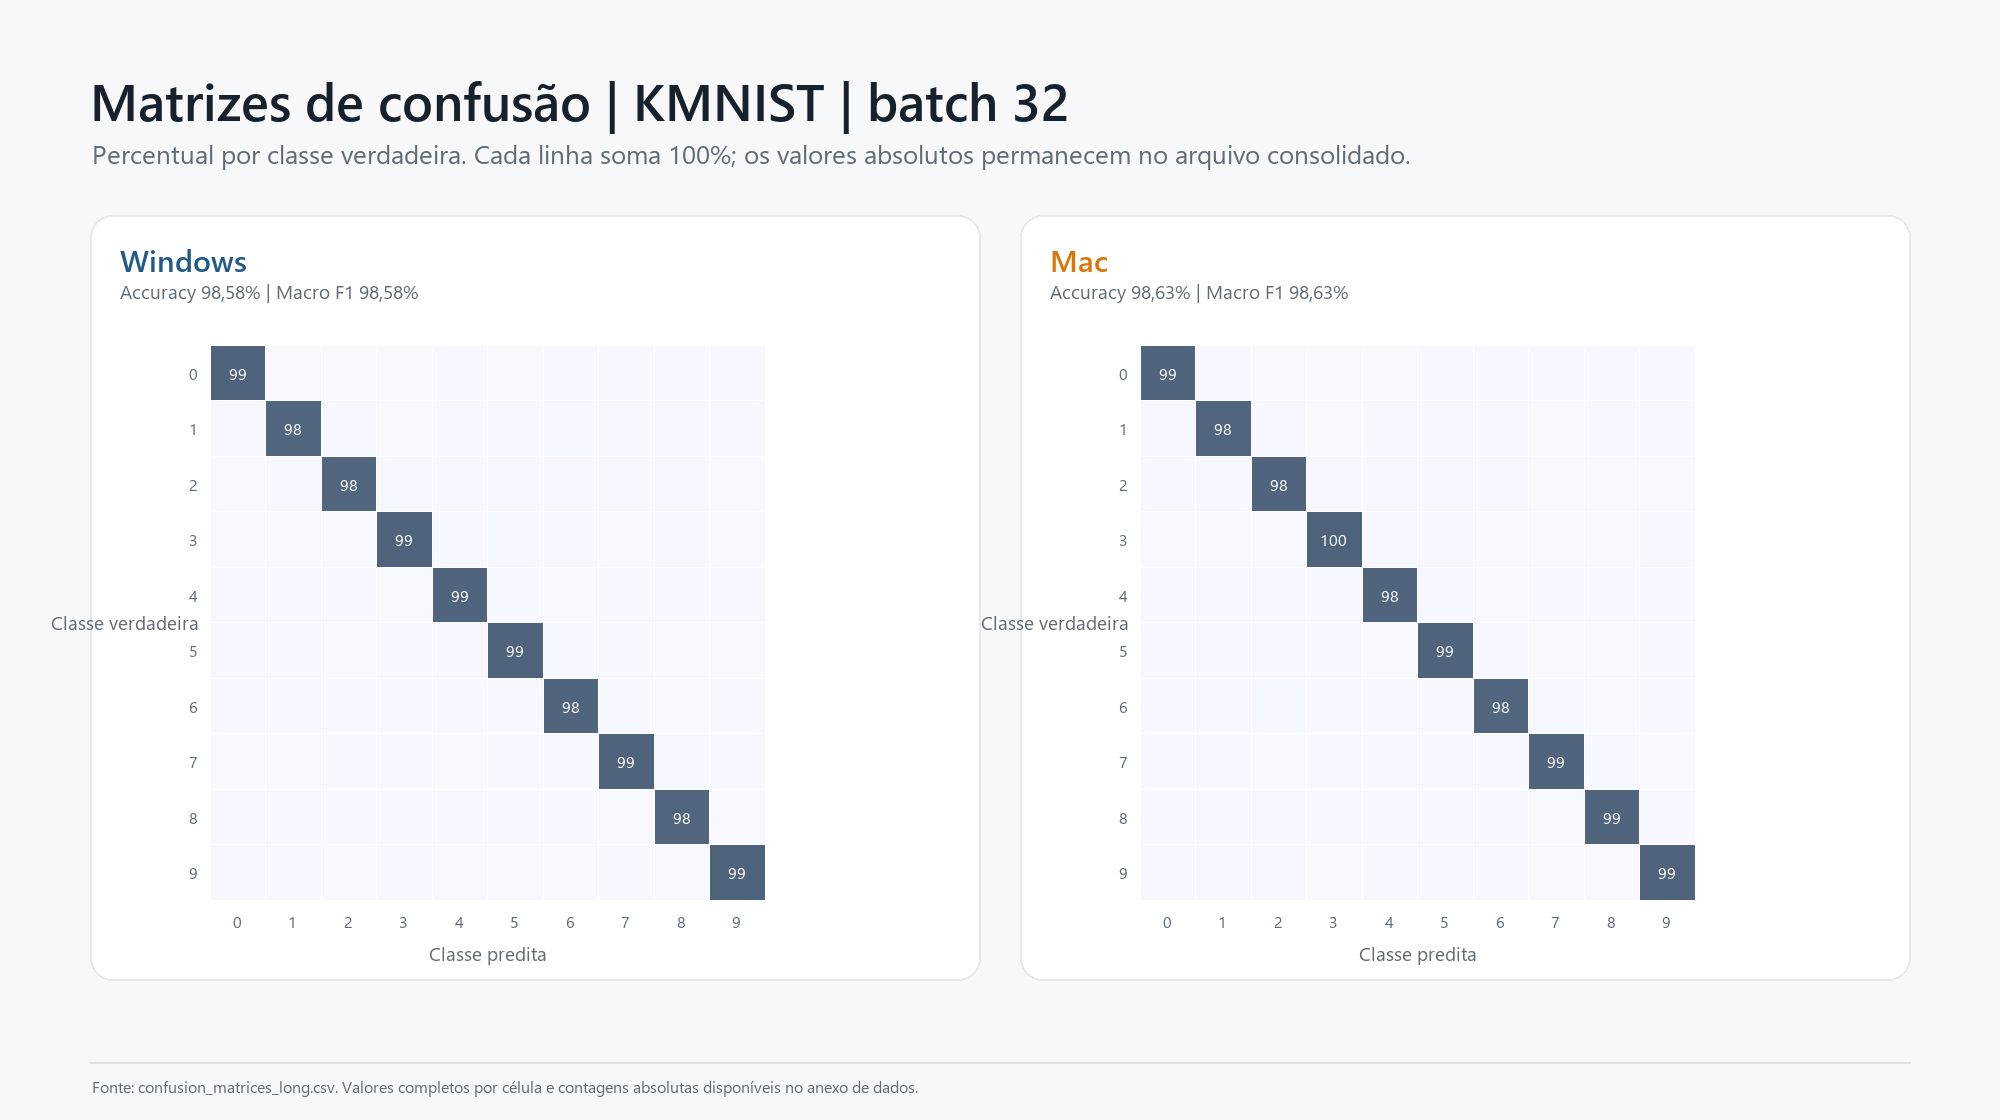

In [27]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / "11_03_matriz_confusao_kmnist_batch_032.png")))


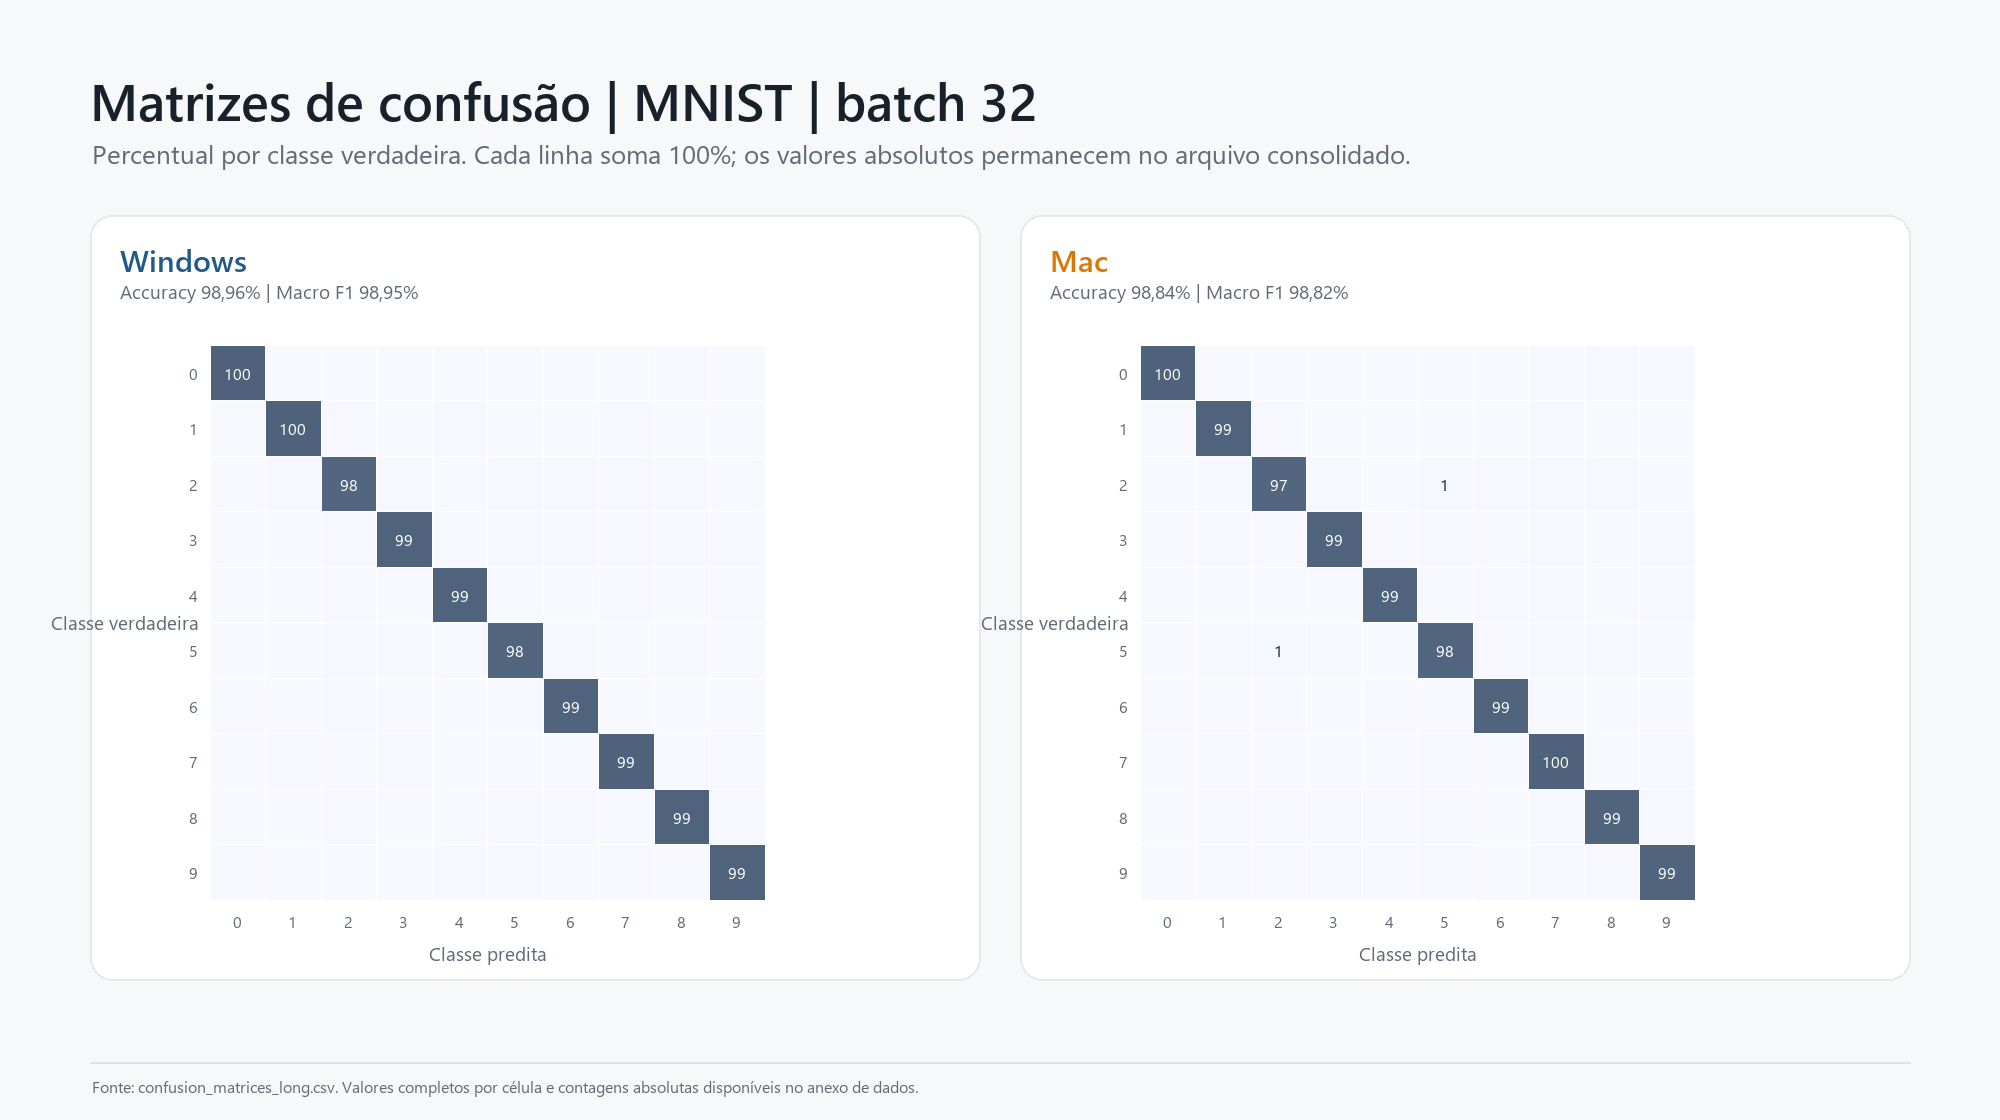

In [28]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / "11_04_matriz_confusao_mnist_batch_032.png")))


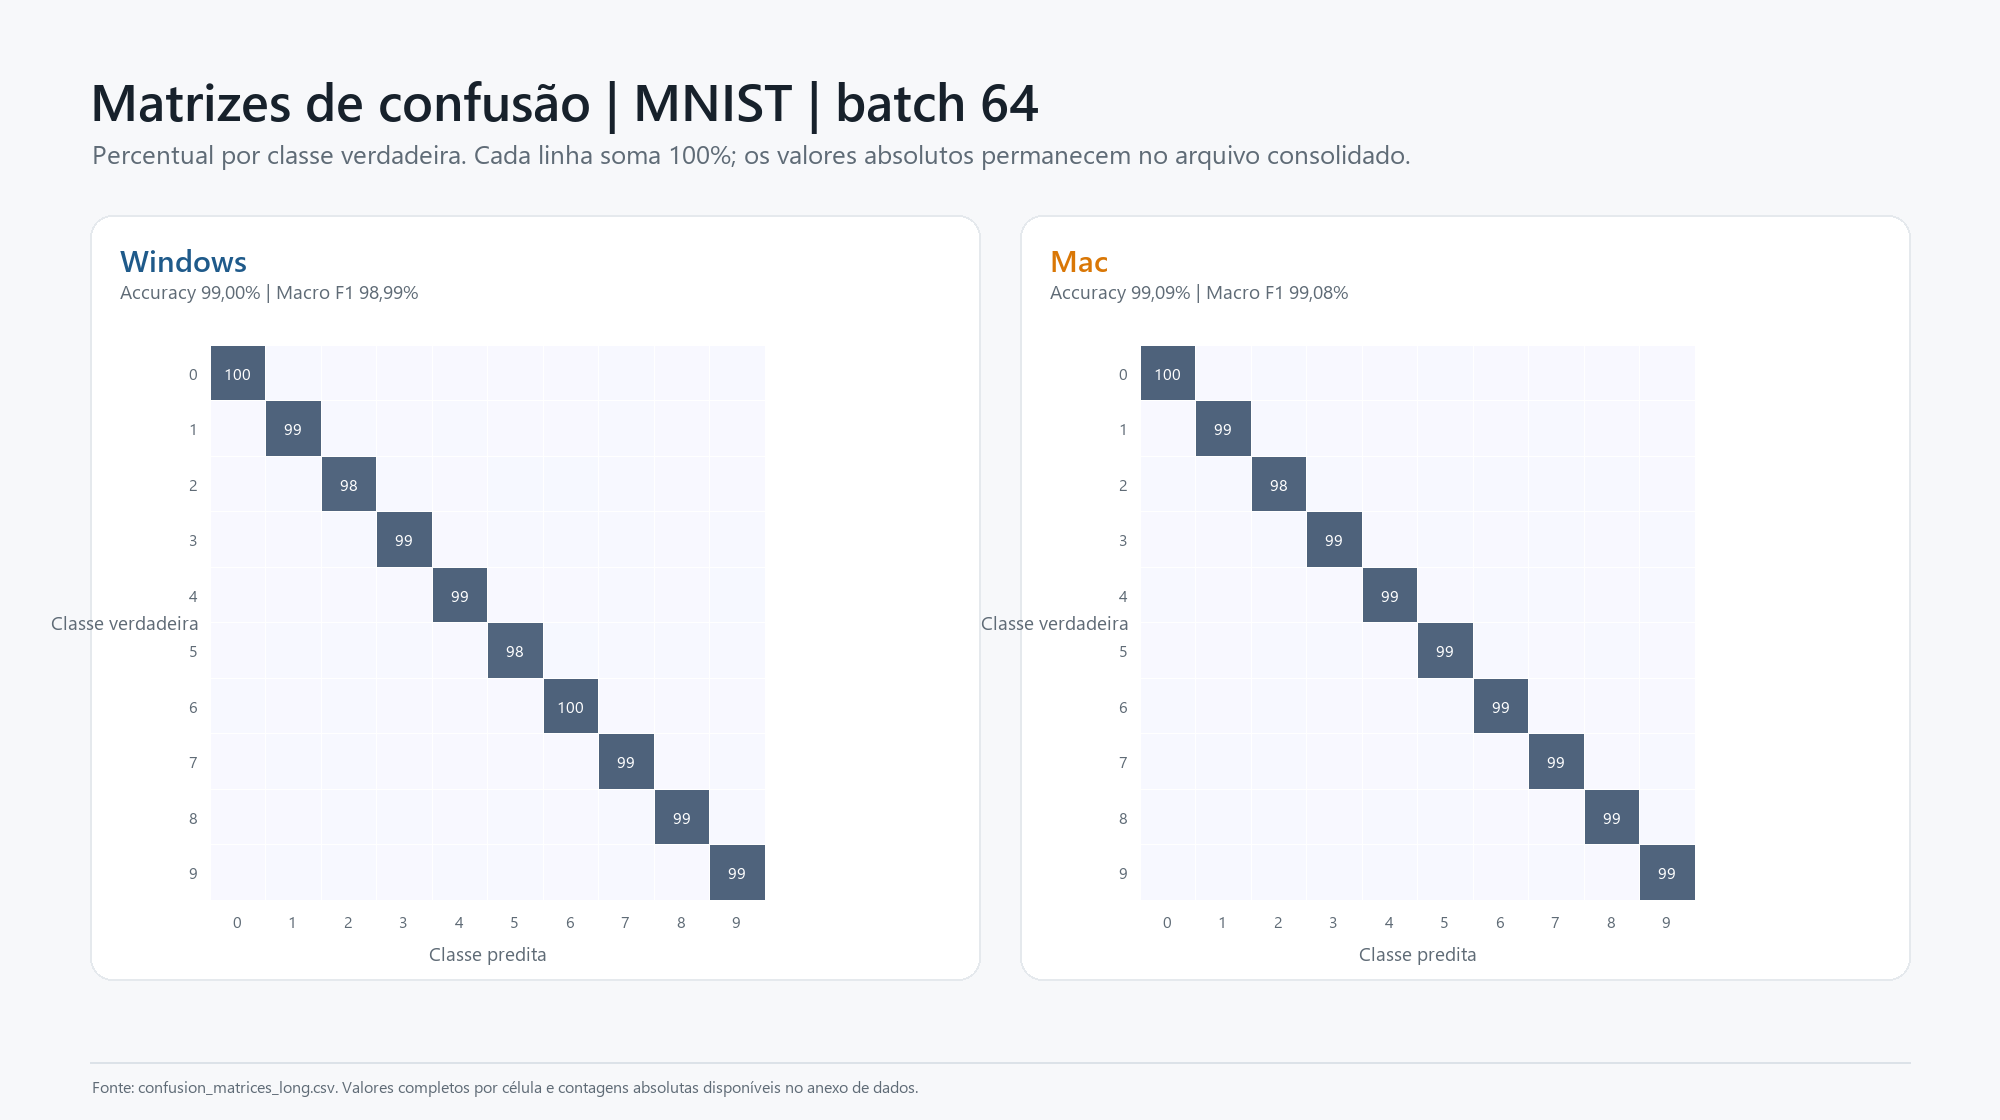

In [29]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / "11_05_matriz_confusao_mnist_batch_064.png")))


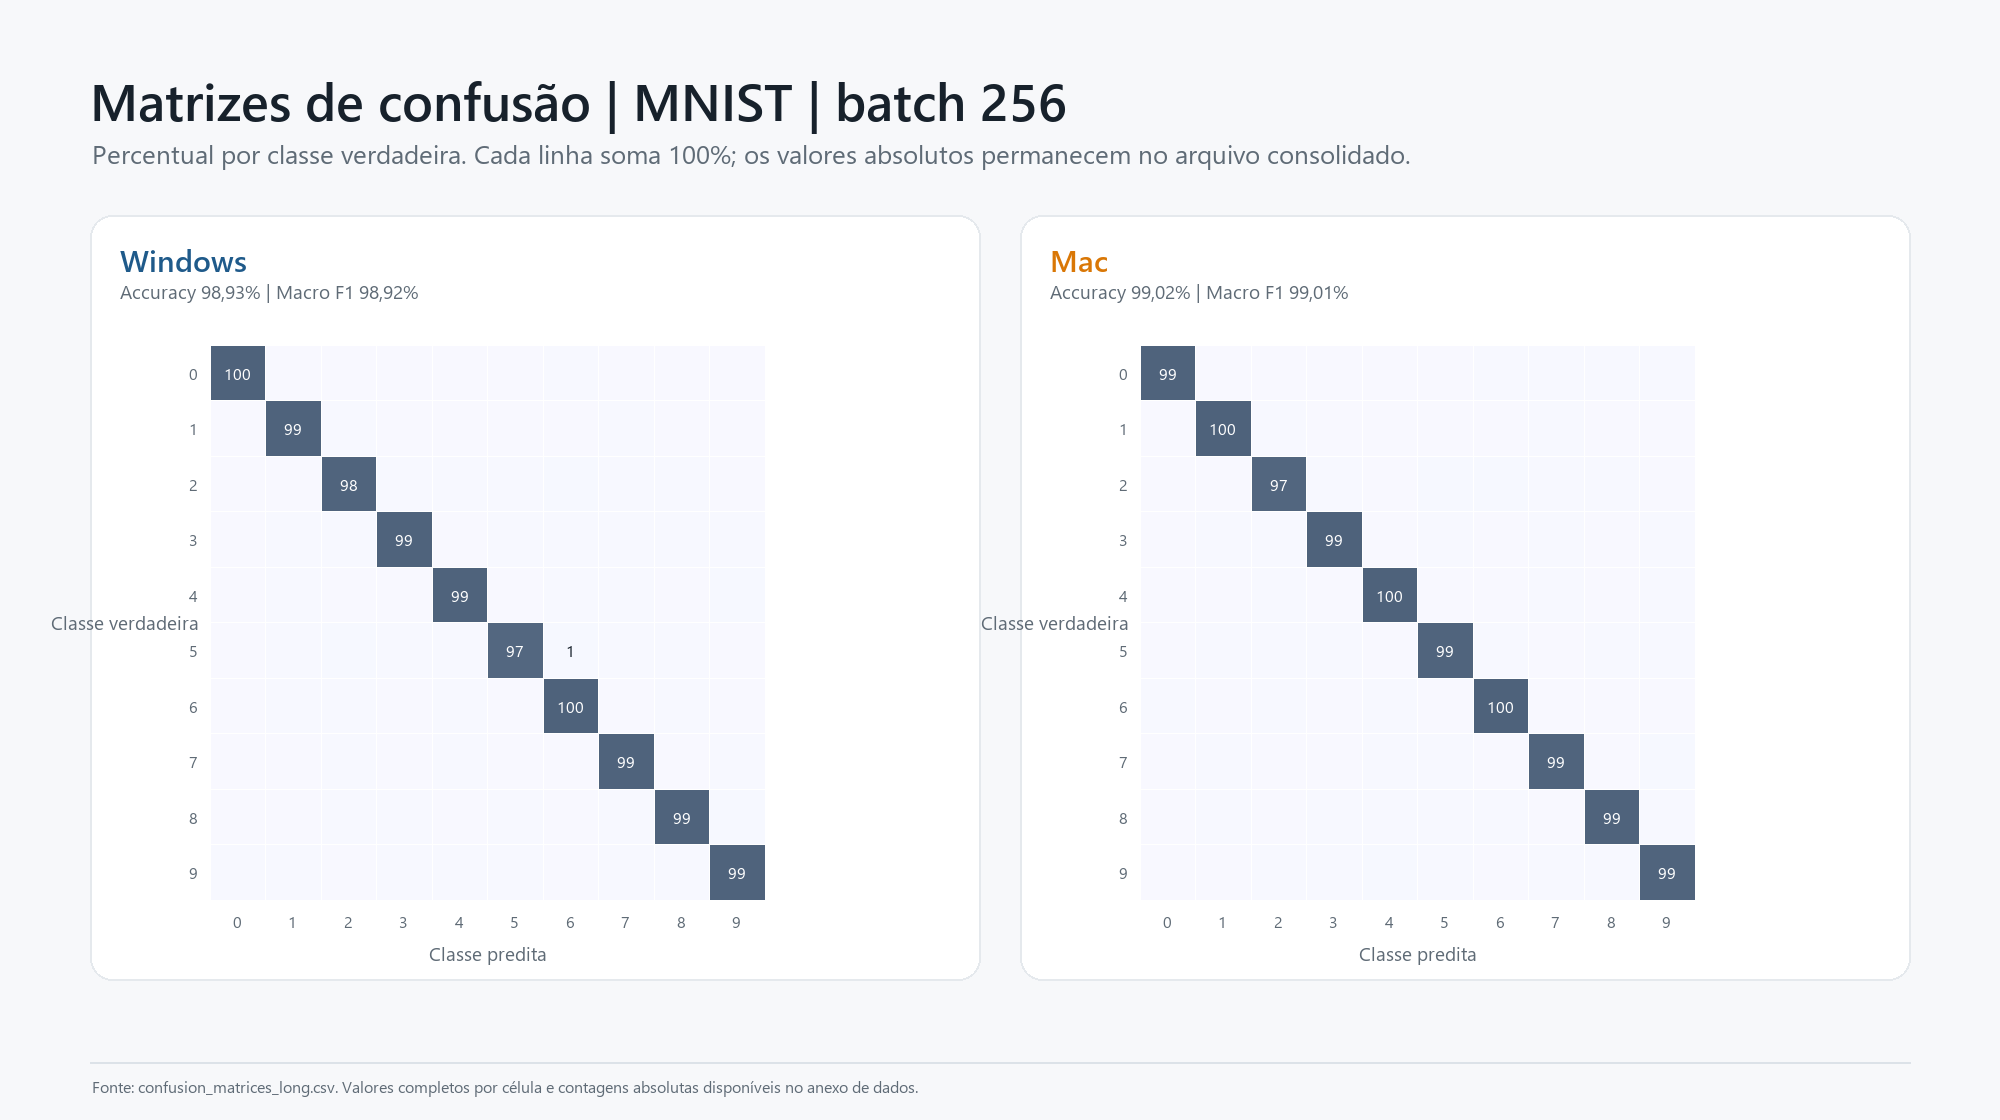

In [30]:
from IPython.display import Image, display
display(Image(filename=str(FIGURES / "11_06_matriz_confusao_mnist_batch_256.png")))


## 11. Lacunas documentadas no Mac


O relatório histórico de batch do Mac registra **16 células concluídas**, mas apenas **6** têm artefatos brutos versionados e comparáveis; **10** são apenas evidência de status/resultado reportado.

Na quantização do Mac, o relatório registra **7 concluídos**, **1 parcial/stale** e **10 não iniciados**. Como os valores exatos não foram versionados, esses itens não entram nos cálculos de desempenho.


In [31]:
mac_batch_reported


platform,campaign,snapshot_date,dataset_key,dataset,batch_size,status,raw_artifact_versioned,evidence_level,is_reported_best,reported_macro_f1,reported_precision,source_path
Mac,controlled-augmentation2-mac-m4-aug05,2026-09-14,cifar10,CIFAR-10,32,completed,False,progress_report_only,True,0.7235,rounded_4_decimals,analysis_reports/relatorio_treinamento_2026-09-14.md
Mac,controlled-augmentation2-mac-m4-aug05,2026-09-14,cifar10,CIFAR-10,64,completed,False,progress_report_only,False,NaN,NaN,analysis_reports/relatorio_treinamento_2026-09-14.md
Mac,controlled-augmentation2-mac-m4-aug05,2026-09-14,cifar10,CIFAR-10,128,completed,False,progress_report_only,False,NaN,NaN,analysis_reports/relatorio_treinamento_2026-09-14.md
Mac,controlled-augmentation2-mac-m4-aug05,2026-09-14,cifar10,CIFAR-10,256,completed,False,progress_report_only,False,NaN,NaN,analysis_reports/relatorio_treinamento_2026-09-14.md
Mac,controlled-augmentation2-mac-m4-aug05,2026-09-14,emnist_balanced,EMNIST Balanced,64,completed,False,progress_report_only,True,0.8780,rounded_4_decimals,analysis_reports/relatorio_treinamento_2026-09-14.md
Mac,controlled-augmentation2-mac-m4-aug05,2026-09-14,emnist_balanced,EMNIST Balanced,128,completed,False,progress_report_only,False,NaN,NaN,analysis_reports/relatorio_treinamento_2026-09-14.md
Mac,controlled-augmentation2-mac-m4-aug05,2026-09-14,emnist_balanced,EMNIST Balanced,256,completed,False,progress_report_only,False,NaN,NaN,analysis_reports/relatorio_treinamento_2026-09-14.md
Mac,controlled-augmentation2-mac-m4-aug05,2026-09-14,fashion_mnist,Fashion-MNIST,128,completed,True,raw_complete,True,0.9112,rounded_4_decimals,analysis_reports/relatorio_treinamento_2026-09-14.md
Mac,controlled-augmentation2-mac-m4-aug05,2026-09-14,fashion_mnist,Fashion-MNIST,256,completed,True,raw_complete,False,NaN,NaN,analysis_reports/relatorio_treinamento_2026-09-14.md
Mac,controlled-augmentation2-mac-m4-aug05,2026-09-14,kmnist,KMNIST,32,completed,True,raw_complete,True,0.9863,rounded_4_decimals,analysis_reports/relatorio_treinamento_2026-09-14.md


In [32]:
mac_quant_reported


platform,campaign,snapshot_date,dataset_key,dataset,variant,status,epochs_observed,has_final_metrics_reported,exact_metric_values_available,evidence_level,source_path
Mac,controlled-quantization-fast-mac-m4,2026-09-14,cifar10,CIFAR-10,fp16,not_started,0,False,False,progress_report_only,analysis_reports/relatorio_progresso_quantizacao_2026-09-10.md
Mac,controlled-quantization-fast-mac-m4,2026-09-14,cifar10,CIFAR-10,fp32,not_started,0,False,False,progress_report_only,analysis_reports/relatorio_progresso_quantizacao_2026-09-10.md
Mac,controlled-quantization-fast-mac-m4,2026-09-14,cifar100_coarse,CIFAR-100 coarse,fp16,not_started,0,False,False,progress_report_only,analysis_reports/relatorio_progresso_quantizacao_2026-09-10.md
Mac,controlled-quantization-fast-mac-m4,2026-09-14,cifar100_coarse,CIFAR-100 coarse,fp32,not_started,0,False,False,progress_report_only,analysis_reports/relatorio_progresso_quantizacao_2026-09-10.md
Mac,controlled-quantization-fast-mac-m4,2026-09-14,emnist_balanced,EMNIST Balanced,fp16,partial_stale,66,False,False,progress_report_only,analysis_reports/relatorio_progresso_quantizacao_2026-09-10.md
Mac,controlled-quantization-fast-mac-m4,2026-09-14,emnist_balanced,EMNIST Balanced,fp32,completed,100,True,False,progress_report_only,analysis_reports/relatorio_progresso_quantizacao_2026-09-10.md
Mac,controlled-quantization-fast-mac-m4,2026-09-14,fashion_mnist,Fashion-MNIST,fp16,completed,100,True,False,progress_report_only,analysis_reports/relatorio_progresso_quantizacao_2026-09-10.md
Mac,controlled-quantization-fast-mac-m4,2026-09-14,fashion_mnist,Fashion-MNIST,fp32,completed,100,True,False,progress_report_only,analysis_reports/relatorio_progresso_quantizacao_2026-09-10.md
Mac,controlled-quantization-fast-mac-m4,2026-09-14,fer2013,FER2013,fp16,not_started,0,False,False,progress_report_only,analysis_reports/relatorio_progresso_quantizacao_2026-09-10.md
Mac,controlled-quantization-fast-mac-m4,2026-09-14,fer2013,FER2013,fp32,not_started,0,False,False,progress_report_only,analysis_reports/relatorio_progresso_quantizacao_2026-09-10.md


## 12. Limitações e interpretação


- Os seis pares batch são a comparação mais forte disponível, mas ainda diferem em hardware, sistema, backend e versão do TensorFlow.
- Os 21 pares de ativação têm batches diferentes; são tendências descritivas, não efeito causal de Windows versus macOS.
- Há uma única seed (`42`) por condição comparada; não há base para intervalos de confiança ou teste de significância entre seeds.
- Os totais de horas são soma de horas por run, não duração de calendário quando houve paralelismo.
- Alguns resultados Mac existem apenas em relatórios agregados; nenhuma métrica ausente foi inferida.
- Softmax foi testada como ativação oculta e apresentou colapso esperado; não se refere à saída softmax padrão do classificador.


## 13. Síntese


1. **Qualidade preditiva nos pares batch:** praticamente equivalente em média; o resultado varia por dataset/batch, sem dominância consistente.
2. **Tempo nos pares batch:** o Windows foi 5,1×–6,6× mais rápido por epoch nos seis pares disponíveis.
3. **Ativações:** ReLU/Sigmoid superam amplamente Softmax oculta; diferenças Windows–Mac nessa campanha são confundidas por batch e stack.
4. **Telemetria:** o Mac reporta utilização percentual maior, enquanto o Windows conclui epochs muito mais rápido; as APIs medem backends distintos.
5. **Evidência:** Windows possui cobertura granular completa para quase todos os runs; no Mac, parte da história permanece somente em relatórios agregados.


## 14. Arquivos de auditoria


In [33]:
inventory


arquivo,linhas,conteudo
run_results.csv,161,"Uma linha por run com métricas finais, tempo, ambiente e telemetria resumida"
class_metrics.csv,2307,"Precisão, recall, F1 e suporte por classe"
confusion_matrices_long.csv,47954,Matrizes de confusão em formato longo
epoch_metrics.csv,10243,"Loss, acurácia, Macro F1, tempo e throughput por epoch"
telemetry_metrics_long.csv,22872,Estatísticas de telemetria por run e métrica
telemetry_profiles.csv,2552,Perfis temporais normalizados de telemetria
comparisons_batch_windows_mac.csv,6,Pares batch com configuração/split equivalentes
comparisons_activation_windows_mac.csv,21,"Pares de ativação descritivos, com batch diferente"
unmatched_runs.csv,107,Runs sem contraparte comparável entre plataformas


Os hashes SHA-256 de todos os CSVs e JSONs consolidados estão em `analysis/consolidacao_resultados/data/checksums.sha256`; a origem de cada run permanece em `source_path`, `source_branch` e `source_commit`.
